In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta
from matplotlib.patches import Rectangle, FancyBboxPatch
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator

# flex needs

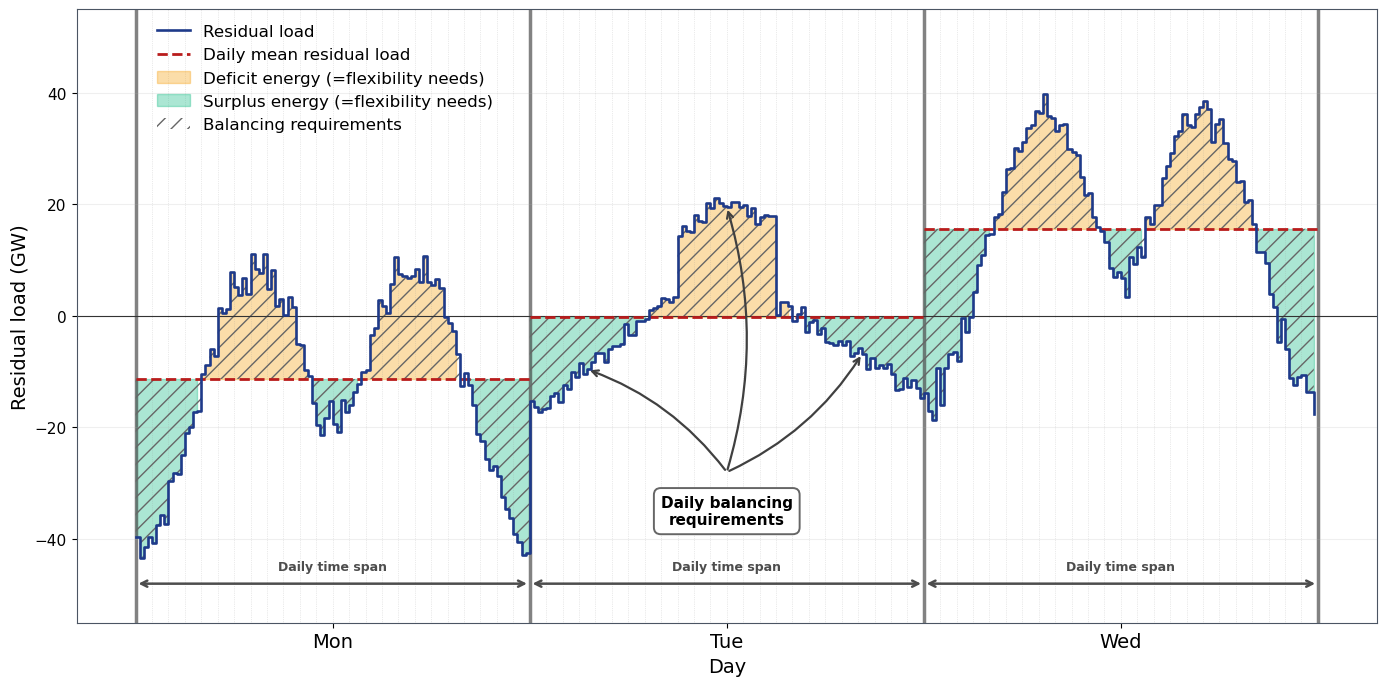

In [2]:
# -----------------------
# Data (deterministic)
# -----------------------
np.random.seed(7)
start = pd.Timestamp('2019-01-01 00:00')
end   = pd.Timestamp('2019-01-03 23:45')
t = pd.date_range(start, end, freq='15min')
day  = (t - t[0]).days
hour = t.hour + t.minute / 60
hrs  = (t - t[0]).total_seconds() / 3600
res = np.zeros(len(t))
for i, (d, h) in enumerate(zip(day, hour)):
    if d == 1:
        if h < 9:
            res[i] = -18 + 2.5*h + np.random.normal(0, 1.2)
        elif h < 15:
            res[i] = 15 + 6*np.sin(np.pi*(h-9)/6) + np.random.normal(0, 1.2)
        else:
            res[i] = 2 - 1.8*(h-15) + np.random.normal(0, 1.2)
    else:
        daily = 18*np.sin(2*np.pi*(h-6)/24) + 10*np.sin(4*np.pi*(h-3)/24)
        solar = -28*np.exp(-((h-12)**2)/8)
        wind  = 15*np.sin(2*np.pi*hrs[i]/48)
        base  = -15 if d == 0 else 12
        res[i] = daily + solar + wind + base + np.random.normal(0, 2)
res = pd.Series(np.clip(res, -50, 50), index=t)
daily_mean = res.resample('D').transform('mean')

# -----------------------
# Figure setup
# -----------------------
plt.rcParams.update({
    'font.size': 11,
    'axes.linewidth': 0.8,
    'axes.edgecolor': '#4B5563'
})
fig, ax = plt.subplots(figsize=(14, 7))
c_res  = '#1E3A8A'
c_pos  = '#F59E0B'
c_neg  = '#10B981'
c_mean = '#B91C1C'

# -----------------------
# Main plot
# -----------------------
ax.step(t, res, where='post', lw=1.9, color=c_res,
        label='Residual load', zorder=4)
for d, v in res.resample('D').mean().items():
    ax.plot([d, d + timedelta(days=1)], [v, v],
            '--', lw=2.0, color=c_mean, zorder=3)
ax.plot([], [], '--', lw=2.0, color=c_mean,
        label='Daily mean residual load')
ax.fill_between(t, daily_mean, res, where=res >= daily_mean,
                step='post', color=c_pos, alpha=0.35,
                label='Deficit energy (=flexibility needs)')
ax.fill_between(t, res, daily_mean, where=res < daily_mean,
                step='post', color=c_neg, alpha=0.35,
                label='Surplus energy (=flexibility needs)')
ax.fill_between(t, daily_mean, res, step='post',
                facecolor='none', hatch='//',
                edgecolor='0.4', lw=0.0,
                label='Balancing requirements', zorder=2)

# -----------------------
# Axes formatting
# -----------------------
# Big vertical lines at the start and end of each day
day_boundaries = pd.date_range(start, end + timedelta(days=1), freq='D')
for d in day_boundaries:
    ax.axvline(d, ls='-', lw=2.5, color='0.3', alpha=0.7, zorder=1)

# Hourly ticks (thin lines)
for h in pd.date_range(start, end, freq='h'):
    if h.hour == 0:  # Skip midnight (already handled by day separator)
        continue
    ax.axvline(h, ls=':', lw=0.5, color='0.6', alpha=0.4, zorder=1)

ax.axhline(0, color='0.2', lw=0.8)
ax.set(
    ylim=(-55, 55),
)
# Set labels and title with larger font sizes
ax.set_ylabel('Residual load (GW)', fontsize=14)
ax.set_xlabel('Day', fontsize=14)
# ax.set_title('Daily flexibility needs', fontsize=16, fontweight='bold', pad=15)

ax.set_xticks([start + timedelta(hours=12),
               start + timedelta(days=1, hours=12),
               start + timedelta(days=2, hours=12)])
ax.set_xticklabels(['Mon', 'Tue', 'Wed'], fontsize=14)
ax.grid(axis='y', alpha=0.2)

# Move legend slightly to the right using bbox_to_anchor
ax.legend(loc='upper left', frameon=False, bbox_to_anchor=(0.05, 1.0), fontsize=12)

# -----------------------
# Annotation (Tuesday)
# -----------------------
d2s = start + timedelta(days=1)
d2e = start + timedelta(days=2)
mask = (t >= d2s) & (t < d2e)
t2, v2 = t[mask], res[mask]
idx = [int(0.15*len(t2)), int(0.5*len(t2)), int(0.85*len(t2))]
targets = [(t2[i], v2.iloc[i]) for i in idx]
anchor_x = d2s + (d2e - d2s) / 2
anchor_y = -28

ax.annotate('Daily balancing\nrequirements',
            xy=targets[1],
            xytext=(anchor_x, -35),
            ha='center', va='center',
            weight='bold',
            bbox=dict(boxstyle='round,pad=0.45',
                      facecolor='white',
                      edgecolor='0.4',
                      lw=1.4))
for tx, ty in targets:
    ax.annotate('', xy=(tx, ty),
                xytext=(anchor_x, anchor_y),
                arrowprops=dict(arrowstyle='->',
                                lw=1.6,
                                connectionstyle='arc3,rad=0.15',
                                color='0.25'))

# -----------------------
# Daily time span brackets (at bottom for all days)
# -----------------------
bracket_y = -48  # Y position for the brackets (near bottom)
bracket_text_y = -46  # Y position for the text ABOVE brackets (changed from -52)

# Create brackets for all 3 days
day_starts = pd.date_range(start, end, freq='D')
day_names = ['Mon', 'Tue', 'Wed']

for i, (day_start, day_name) in enumerate(zip(day_starts[:3], day_names)):
    day_end = day_start + timedelta(days=1)
    day_center = day_start + timedelta(hours=12)
    
    # Draw horizontal line with arrows at the ends
    ax.annotate('', xy=(day_start, bracket_y), xytext=(day_end, bracket_y),
                arrowprops=dict(arrowstyle='<->', lw=1.8, color='0.3'))
    
    # Add text ABOVE the bracket
    ax.text(day_center, bracket_text_y, 'Daily time span',
            ha='center', va='bottom', fontsize=9, weight='bold', color='0.3')

plt.tight_layout()
plt.savefig('/home/julian-geis/Documents/06_PhD/02Flexibility/plots/methods/daily_flexibility_needs.png', dpi=300, bbox_inches='tight')
plt.show()

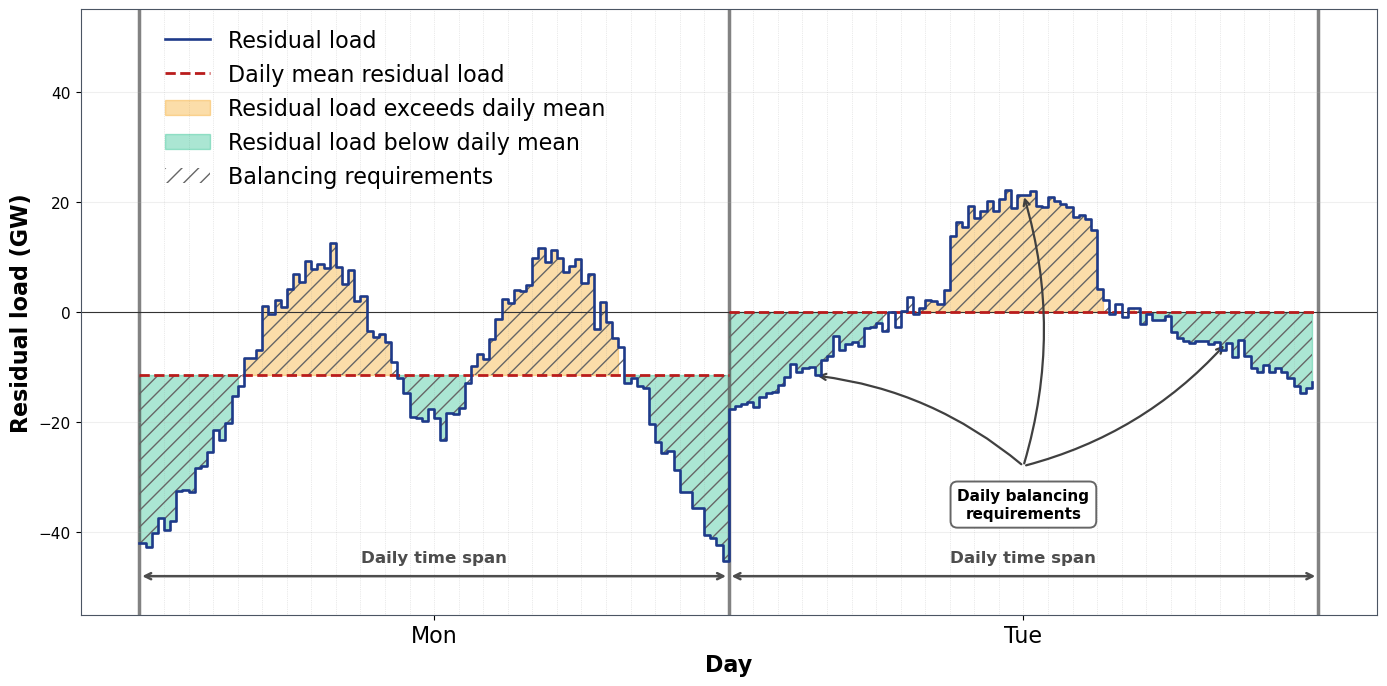

In [3]:
# -----------------------
# Data (deterministic) - ONLY 2 DAYS
# -----------------------
np.random.seed(42)
start = pd.Timestamp('2019-01-01 00:00')
end   = pd.Timestamp('2019-01-02 23:45')  # Changed from 01-03 to 01-02
t = pd.date_range(start, end, freq='15min')
day  = (t - t[0]).days
hour = t.hour + t.minute / 60
hrs  = (t - t[0]).total_seconds() / 3600
res = np.zeros(len(t))
for i, (d, h) in enumerate(zip(day, hour)):
    if d == 1:
        if h < 9:
            res[i] = -18 + 2.5*h + np.random.normal(0, 1.2)
        elif h < 15:
            res[i] = 15 + 6*np.sin(np.pi*(h-9)/6) + np.random.normal(0, 1.2)
        else:
            res[i] = 2 - 1.8*(h-15) + np.random.normal(0, 1.2)
    else:
        daily = 18*np.sin(2*np.pi*(h-6)/24) + 10*np.sin(4*np.pi*(h-3)/24)
        solar = -28*np.exp(-((h-12)**2)/8)
        wind  = 15*np.sin(2*np.pi*hrs[i]/48)
        base  = -15 if d == 0 else 12
        res[i] = daily + solar + wind + base + np.random.normal(0, 2)
res = pd.Series(np.clip(res, -50, 50), index=t)
daily_mean = res.resample('D').transform('mean')

# -----------------------
# Figure setup
# -----------------------
plt.rcParams.update({
    'font.size': 11,
    'axes.linewidth': 0.8,
    'axes.edgecolor': '#4B5563'
})
fig, ax = plt.subplots(figsize=(14, 7))
c_res  = '#1E3A8A'
c_pos  = '#F59E0B'
c_neg  = '#10B981'
c_mean = '#B91C1C'

# -----------------------
# Main plot
# -----------------------
ax.step(t, res, where='post', lw=1.9, color=c_res,
        label='Residual load', zorder=4)
for d, v in res.resample('D').mean().items():
    ax.plot([d, d + timedelta(days=1)], [v, v],
            '--', lw=2.0, color=c_mean, zorder=3)
ax.plot([], [], '--', lw=2.0, color=c_mean,
        label='Daily mean residual load')
ax.fill_between(t, daily_mean, res, where=res >= daily_mean,
                step='post', color=c_pos, alpha=0.35,
                label='Residual load exceeds daily mean')
ax.fill_between(t, res, daily_mean, where=res < daily_mean,
                step='post', color=c_neg, alpha=0.35,
                label='Residual load below daily mean')
ax.fill_between(t, daily_mean, res, step='post',
                facecolor='none', hatch='//',
                edgecolor='0.4', lw=0.0,
                label='Balancing requirements', zorder=2)

# -----------------------
# Axes formatting
# -----------------------
# Big vertical lines at the start and end of each day
day_boundaries = pd.date_range(start, end + timedelta(days=1), freq='D')
for d in day_boundaries:
    ax.axvline(d, ls='-', lw=2.5, color='0.3', alpha=0.7, zorder=1)

# Hourly ticks (thin lines)
for h in pd.date_range(start, end, freq='h'):
    if h.hour == 0:  # Skip midnight (already handled by day separator)
        continue
    ax.axvline(h, ls=':', lw=0.5, color='0.6', alpha=0.4, zorder=1)

ax.axhline(0, color='0.2', lw=0.8)
ax.set(
    ylim=(-55, 55),
)
# Set labels and title with larger font sizes
ax.set_ylabel('Residual load (GW)', fontsize=16, fontweight='bold')
ax.set_xlabel('Day', fontsize=16, fontweight='bold')
# ax.set_title('Daily flexibility needs', fontsize=16, fontweight='bold', pad=15)

ax.set_xticks([start + timedelta(hours=12),
               start + timedelta(days=1, hours=12)])  # Only 2 days
ax.set_xticklabels(['Mon', 'Tue'], fontsize=16)  # Only Mon and Tue
ax.grid(axis='y', alpha=0.2)

# Move legend slightly to the right using bbox_to_anchor
ax.legend(loc='upper left', frameon=False, bbox_to_anchor=(0.05, 1.0), fontsize=16)

# -----------------------
# Annotation (Tuesday)
# -----------------------
d2s = start + timedelta(days=1)
d2e = start + timedelta(days=2)
mask = (t >= d2s) & (t < d2e)
t2, v2 = t[mask], res[mask]
idx = [int(0.15*len(t2)), int(0.5*len(t2)), int(0.85*len(t2))]
targets = [(t2[i], v2.iloc[i]) for i in idx]
anchor_x = d2s + (d2e - d2s) / 2
anchor_y = -28

ax.annotate('Daily balancing\nrequirements',
            xy=targets[1],
            xytext=(anchor_x, -35),
            ha='center', va='center',
            weight='bold',
            bbox=dict(boxstyle='round,pad=0.45',
                      facecolor='white',
                      edgecolor='0.4',
                      lw=1.4))
for tx, ty in targets:
    ax.annotate('', xy=(tx, ty),
                xytext=(anchor_x, anchor_y),
                arrowprops=dict(arrowstyle='->',
                                lw=1.6,
                                connectionstyle='arc3,rad=0.15',
                                color='0.25'))

# -----------------------
# Daily time span brackets (at bottom for all days)
# -----------------------
bracket_y = -48  # Y position for the brackets (near bottom)
bracket_text_y = -46  # Y position for the text ABOVE brackets

# Create brackets for only 2 days
day_starts = pd.date_range(start, end, freq='D')
day_names = ['Mon', 'Tue']  # Only 2 days

for i, (day_start, day_name) in enumerate(zip(day_starts[:2], day_names)):  # Only first 2
    day_end = day_start + timedelta(days=1)
    day_center = day_start + timedelta(hours=12)
    
    # Draw horizontal line with arrows at the ends
    ax.annotate('', xy=(day_start, bracket_y), xytext=(day_end, bracket_y),
                arrowprops=dict(arrowstyle='<->', lw=1.8, color='0.3'))
    
    # Add text ABOVE the bracket
    ax.text(day_center, bracket_text_y, 'Daily time span',
            ha='center', va='bottom', fontsize=12, weight='bold', color='0.3')

plt.tight_layout()
plt.savefig('/home/julian-geis/Documents/06_PhD/02Flexibility/plots/methods/daily_flexibility_needs_two_days.png', dpi=300, bbox_inches='tight')
plt.show()

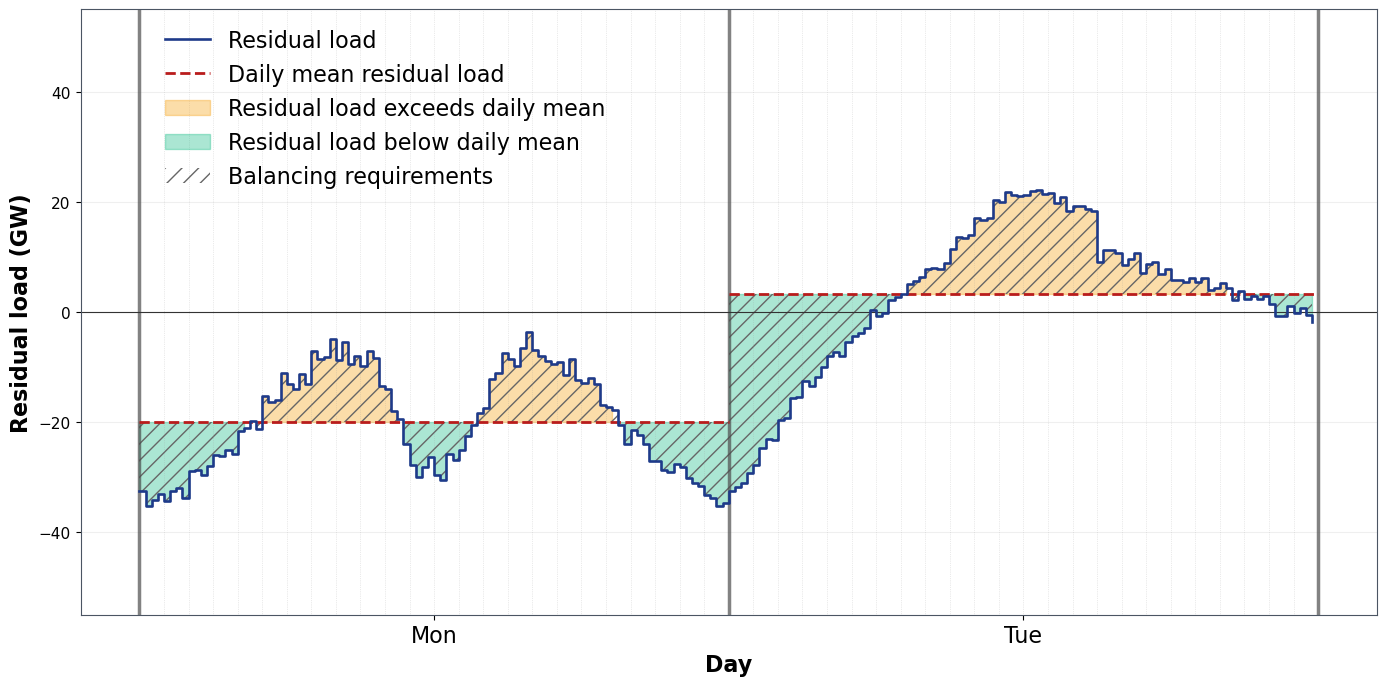

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta

# -----------------------
# Setup
# -----------------------
np.random.seed(7)

start = pd.Timestamp('2019-01-01 00:00')
end   = pd.Timestamp('2019-01-02 23:45')

t = pd.date_range(start, end, freq='15min')
hour = t.hour + t.minute / 60

res = np.zeros(len(t))

# -----------------------
# DAY 1 (surplus)
# -----------------------
mask_day1 = t < (start + timedelta(days=1))
t1 = t[mask_day1]
h1 = hour[mask_day1]
hrs1 = (t1 - t1[0]).total_seconds() / 3600

for i, h in enumerate(h1):
    daily = 15*np.sin(2*np.pi*(h-6)/24)
    solar = -35*np.exp(-((h-12)**2)/6)
    wind  = 10*np.sin(2*np.pi*hrs1[i]/48)
    base  = -20
    res[i] = daily + solar + wind + base + np.random.normal(0, 1.5)

# Anchor value (continuity condition)
anchor = res[len(t1)-1]

# -----------------------
# DAY 2 (build shape FIRST)
# -----------------------
mask_day2 = ~mask_day1
t2 = t[mask_day2]
h2 = hour[mask_day2]

shape = np.zeros(len(t2))

for i, h in enumerate(h2):
    if h < 9:
        shape[i] = 2.0*h
    elif h < 15:
        shape[i] = 20 + 8*np.sin(np.pi*(h-9)/6)
    else:
        shape[i] = 15 - 1.5*(h-15)

# -----------------------
# Step 1: enforce continuity
# -----------------------
shape = shape - shape[0] + anchor  # first value EXACTLY matches day 1 end

# -----------------------
# Step 2: enforce positive mean WITHOUT breaking continuity
# -----------------------
target_mean = 10
current_mean = shape.mean()

# adjustment that keeps first value fixed
adjustment = target_mean - current_mean

# apply only to deviations from first value
shape = shape + adjustment * (1 - np.exp(-np.arange(len(shape))/20))

# add small noise AFTER constraints
shape += np.random.normal(0, 1.0, len(shape))

# insert into full series
res[mask_day2] = shape

# -----------------------
# Finalize
# -----------------------
res = pd.Series(np.clip(res, -50, 50), index=t)
daily_mean = res.resample('D').transform('mean')

# -----------------------
# Plot (unchanged)
# -----------------------
plt.rcParams.update({
    'font.size': 11,
    'axes.linewidth': 0.8,
    'axes.edgecolor': '#4B5563'
})

fig, ax = plt.subplots(figsize=(14, 7))

c_res  = '#1E3A8A'
c_pos  = '#F59E0B'
c_neg  = '#10B981'
c_mean = '#B91C1C'

ax.step(t, res, where='post', lw=1.9, color=c_res,
        label='Residual load', zorder=4)

for d, v in res.resample('D').mean().items():
    ax.plot([d, d + timedelta(days=1)], [v, v],
            '--', lw=2.0, color=c_mean, zorder=3)

ax.plot([], [], '--', lw=2.0, color=c_mean,
        label='Daily mean residual load')

ax.fill_between(t, daily_mean, res, where=res >= daily_mean,
                step='post', color=c_pos, alpha=0.35,
                label='Residual load exceeds daily mean')

ax.fill_between(t, res, daily_mean, where=res < daily_mean,
                step='post', color=c_neg, alpha=0.35,
                label='Residual load below daily mean')

ax.fill_between(t, daily_mean, res, step='post',
                facecolor='none', hatch='//',
                edgecolor='0.4', lw=0.0,
                label='Balancing requirements', zorder=2)

# formatting
for d in pd.date_range(start, end + timedelta(days=1), freq='D'):
    ax.axvline(d, lw=2.5, color='0.3', alpha=0.7)

for h in pd.date_range(start, end, freq='h'):
    if h.hour != 0:
        ax.axvline(h, ls=':', lw=0.5, color='0.6', alpha=0.4)

ax.axhline(0, color='0.2', lw=0.8)

ax.set(ylim=(-55, 55))
ax.set_ylabel('Residual load (GW)', fontsize=16, fontweight='bold')
ax.set_xlabel('Day', fontsize=16, fontweight='bold')

ax.set_xticks([start + timedelta(hours=12),
               start + timedelta(days=1, hours=12)])
ax.set_xticklabels(['Mon', 'Tue'], fontsize=16)

ax.grid(axis='y', alpha=0.2)

ax.legend(loc='upper left', frameon=False,
          bbox_to_anchor=(0.05, 1.0), fontsize=16)

plt.tight_layout()
plt.savefig('/home/julian-geis/Documents/06_PhD/02Flexibility/plots/methods/daily_flexibility_needs_two_days.png', dpi=300, bbox_inches='tight')
plt.show()

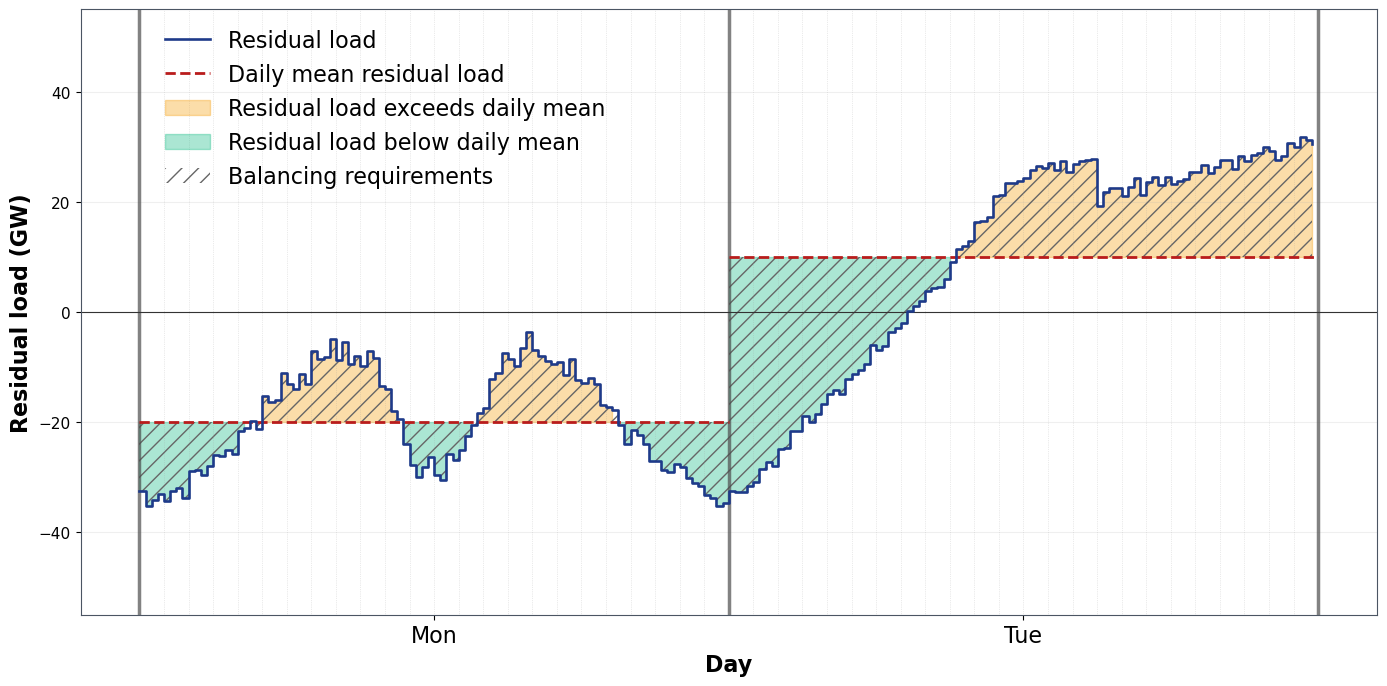

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta

# -----------------------
# Setup
# -----------------------
np.random.seed(7)

start = pd.Timestamp('2019-01-01 00:00')
end   = pd.Timestamp('2019-01-02 23:45')

t = pd.date_range(start, end, freq='15min')
hour = t.hour + t.minute / 60

res = np.zeros(len(t))

# -----------------------
# DAY 1 (surplus)
# -----------------------
mask_day1 = t < (start + timedelta(days=1))
t1 = t[mask_day1]
h1 = hour[mask_day1]
hrs1 = (t1 - t1[0]).total_seconds() / 3600

for i, h in enumerate(h1):
    daily = 15*np.sin(2*np.pi*(h-6)/24)
    solar = -35*np.exp(-((h-12)**2)/6)
    wind  = 10*np.sin(2*np.pi*hrs1[i]/48)
    base  = -20
    res[i] = daily + solar + wind + base + np.random.normal(0, 1.5)

# Anchor value (continuity)
anchor = res[len(t1)-1]

# -----------------------
# DAY 2 (clean analytical construction)
# -----------------------
mask_day2 = ~mask_day1
t2 = t[mask_day2]
h2 = hour[mask_day2]

# Base shape (no level yet)
shape = np.zeros(len(t2))
for i, h in enumerate(h2):
    if h < 9:
        shape[i] = 2.0*h
    elif h < 15:
        shape[i] = 20 + 8*np.sin(np.pi*(h-9)/6)
    else:
        shape[i] = 15 - 1.5*(h-15)

# Normalize so first value = 0
shape = shape - shape[0]

# Time index normalized [0,1]
tau = np.linspace(0, 1, len(shape))

# -----------------------
# Solve analytically for tilt (b)
# -----------------------
target_mean = 10

# Mean components
mean_shape = shape.mean()
mean_tau   = tau.mean()

# We want:
# anchor + mean_shape + b * mean_tau = target_mean
b = (target_mean - anchor - mean_shape) / mean_tau

# Final day 2
res_day2 = anchor + shape + b * tau

# Add small noise (optional but realistic)
res_day2 += np.random.normal(0, 1.0, len(res_day2))

# Insert
res[mask_day2] = res_day2

# -----------------------
# Finalize
# -----------------------
res = pd.Series(np.clip(res, -50, 50), index=t)
daily_mean = res.resample('D').transform('mean')

# -----------------------
# Plot
# -----------------------
plt.rcParams.update({
    'font.size': 11,
    'axes.linewidth': 0.8,
    'axes.edgecolor': '#4B5563'
})

fig, ax = plt.subplots(figsize=(14, 7))

c_res  = '#1E3A8A'
c_pos  = '#F59E0B'
c_neg  = '#10B981'
c_mean = '#B91C1C'

ax.step(t, res, where='post', lw=1.9, color=c_res,
        label='Residual load', zorder=4)

for d, v in res.resample('D').mean().items():
    ax.plot([d, d + timedelta(days=1)], [v, v],
            '--', lw=2.0, color=c_mean, zorder=3)

ax.plot([], [], '--', lw=2.0, color=c_mean,
        label='Daily mean residual load')

ax.fill_between(t, daily_mean, res, where=res >= daily_mean,
                step='post', color=c_pos, alpha=0.35,
                label='Residual load exceeds daily mean')

ax.fill_between(t, res, daily_mean, where=res < daily_mean,
                step='post', color=c_neg, alpha=0.35,
                label='Residual load below daily mean')

ax.fill_between(t, daily_mean, res, step='post',
                facecolor='none', hatch='//',
                edgecolor='0.4', lw=0.0,
                label='Balancing requirements', zorder=2)

# formatting
for d in pd.date_range(start, end + timedelta(days=1), freq='D'):
    ax.axvline(d, lw=2.5, color='0.3', alpha=0.7)

for h in pd.date_range(start, end, freq='h'):
    if h.hour != 0:
        ax.axvline(h, ls=':', lw=0.5, color='0.6', alpha=0.4)

ax.axhline(0, color='0.2', lw=0.8)

ax.set(ylim=(-55, 55))
ax.set_ylabel('Residual load (GW)', fontsize=16, fontweight='bold')
ax.set_xlabel('Day', fontsize=16, fontweight='bold')

ax.set_xticks([start + timedelta(hours=12),
               start + timedelta(days=1, hours=12)])
ax.set_xticklabels(['Mon', 'Tue'], fontsize=16)

ax.grid(axis='y', alpha=0.2)

ax.legend(loc='upper left', frameon=False,
          bbox_to_anchor=(0.05, 1.0), fontsize=16)

plt.tight_layout()
plt.show()

# flex contributions

Daily flexibility needs: 60.0 GWh
Solar flexibility contribution: 9.0 GWh
Gas flexibility contribution: 19.5 GWh

✓ Flexibility provision plot saved

Calculations:
Daily flexibility needs = 0.5 × (|36-44| + |48-44| + |52-44| + |46-44| + |42-44| + |38-44| + |50-44| + |40-44|) × 3h = 60.0 GWh
Solar flexibility contribution = 0.5 × (-4×-1 + -4×+1 + +0×+1 + +10×+1 + +6×-1 + -2×-1 + -4×+1 + -4×-1) × 3h = 9.0 GWh
Gas flexibility contribution = 0.5 × (-3×-1 + +1×+1 + +3×+1 + +0×+1 + -1×-1 + -2×-1 + +2×+1 + -1×-1) × 3h = 19.5 GWh


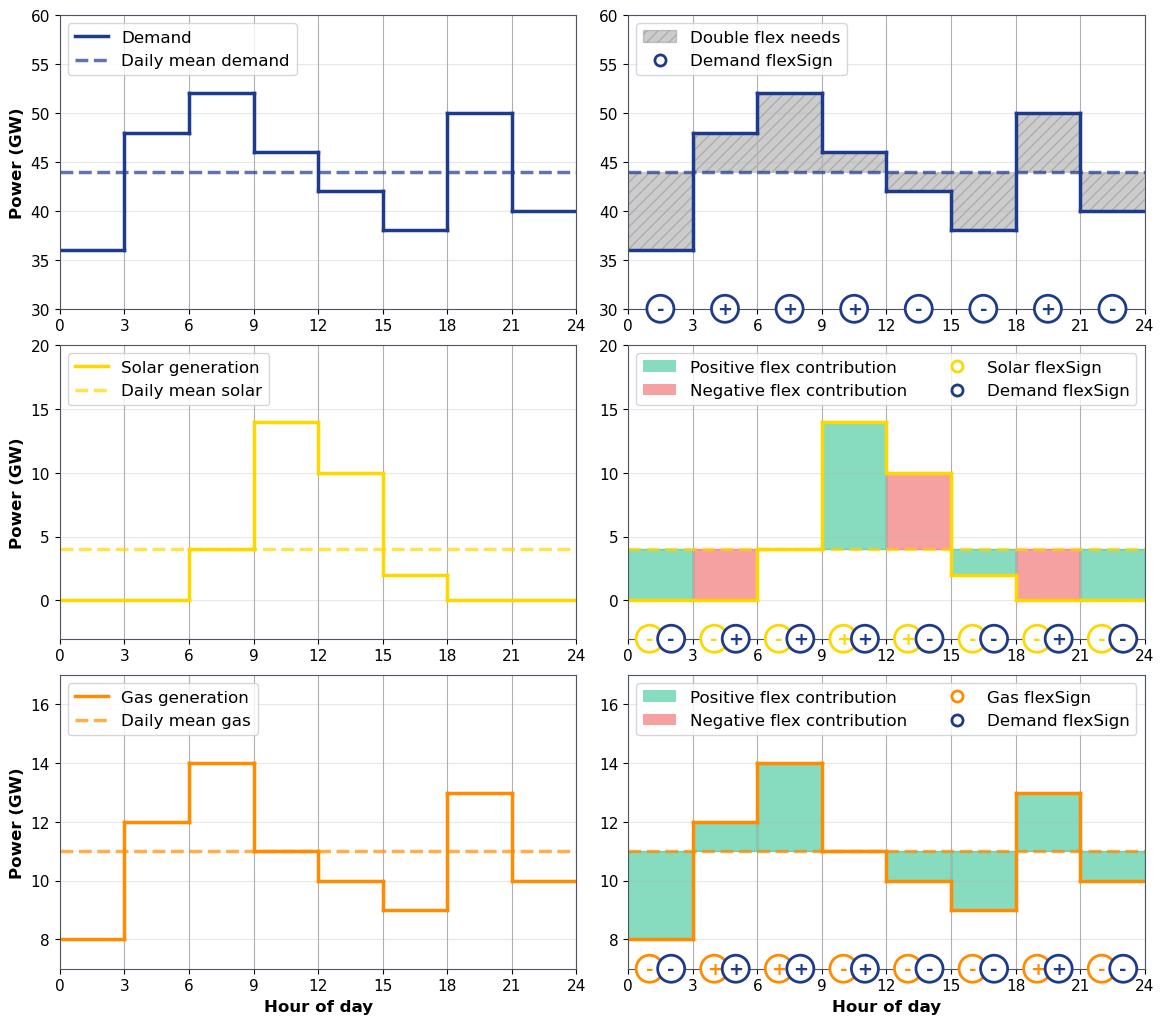

In [ ]:
# -----------------------
# Data setup - 3 hour resolution for one day
# -----------------------
np.random.seed(42)
start = pd.Timestamp('2019-01-01 00:00')
end = pd.Timestamp('2019-01-01 21:00')
t = pd.date_range(start, end, freq='3h')
hour = t.hour

# Net demand (residual load) - morning and evening peaks with cleaner numbers
net_demand = np.array([36, 48, 52, 46, 42, 38, 50, 40])  # Clean values in GW
net_demand = pd.Series(net_demand, index=t)
net_demand_mean = net_demand.mean()  # Will be 44.0 GW

# Solar generation - only from 6h to 18h (zero otherwise) - clean numbers
solar = np.array([0, 0, 4, 14, 10, 2, 0, 0])  # Clean values, mean = 3.75 ≈ 4.0
solar = pd.Series(solar, index=t)
solar_mean = 4.0  # Set to clean number

# Gas generation - follows net demand with clean numbers
gas = np.array([8, 12, 14, 11, 10, 9, 13, 10])  # Mean = 10.875 ≈ 11.0
gas = pd.Series(gas, index=t)
gas_mean = 11.0  # Set to clean number

# Calculate flexibility sign from net demand
flex_sign = np.sign(net_demand - net_demand_mean)
prod_sign_solar = np.sign(solar - solar_mean)
prod_sign_gas = np.sign(gas - gas_mean)

# Calculate flexibility needs (net demand) in GWh
flex_needs = 0.5 * np.sum(np.abs(net_demand - net_demand_mean)) * 3  # GWh

# Calculate flexibility contributions in GWh
solar_flex_curve = (solar - solar_mean) * flex_sign
gas_flex_curve = (gas - gas_mean) * flex_sign

solar_contribution = 0.5 * np.sum(solar_flex_curve) * 3   # GWh (×3 for 3h intervals)
gas_contribution = 0.5 * np.sum(gas_flex_curve) * 3   # GWh

print(f"Daily flexibility needs: {flex_needs:.1f} GWh")
print(f"Solar flexibility contribution: {solar_contribution:.1f} GWh")
print(f"Gas flexibility contribution: {gas_contribution:.1f} GWh")

# Helper function to format numbers without trailing .0
def format_num(val):
    if val == int(val):
        return f"{int(val)}"
    else:
        return f"{val:.1f}"

# Helper function to add sign to string
def format_with_sign(val):
    num_str = format_num(abs(val))
    if val >= 0:
        return f"+{num_str}"
    else:
        return f"-{num_str}"

# Build calculation strings
flex_needs_calc = "Daily flexibility needs = 0.5 × ("
for i in range(len(hour)):
    nd_val = format_num(net_demand.iloc[i])
    mean_val = format_num(net_demand_mean)
    flex_needs_calc += f"|{nd_val}-{mean_val}|"
    if i < len(hour) - 1:
        flex_needs_calc += " + "
flex_needs_calc += f") × 3h = {flex_needs:.1f} GWh"

solar_calc = "Solar flexibility contribution = 0.5 × ("
for i in range(len(hour)):
    prod_val = solar.iloc[i] - solar_mean
    sign_val = int(flex_sign.iloc[i])
    prod_str = format_with_sign(prod_val)
    solar_calc += f"{prod_str}×{sign_val:+d}"
    if i < len(hour) - 1:
        solar_calc += " + "
solar_calc += f") × 3h = {solar_contribution:.1f} GWh"

gas_calc = "Gas flexibility contribution = 0.5 × ("
for i in range(len(hour)):
    prod_val = gas.iloc[i] - gas_mean
    sign_val = int(flex_sign.iloc[i])
    prod_str = format_with_sign(prod_val)
    gas_calc += f"{prod_str}×{sign_val:+d}"
    if i < len(hour) - 1:
        gas_calc += " + "
gas_calc += f") × 3h = {gas_contribution:.1f} GWh"

# -----------------------
# Create the plot
# -----------------------
plt.rcParams.update({
    'font.size': 11,
    'axes.linewidth': 0.8,
})

fig = plt.figure(figsize=(14, 14))
gs = fig.add_gridspec(4, 2, hspace=0.15, wspace=0.1, height_ratios=[1, 1, 1, 0.3])
axes = [[fig.add_subplot(gs[i, j]) for j in range(2)] for i in range(3)]

# Colors
c_net = '#1E3A8A'
c_solar = '#FFD700'  # Gold
c_gas = '#FF8C00'    # Dark orange
c_pos = '#10B981'  # Green for positive
c_neg = '#EF4444'  # Red for negative

# -----------------------
# Row 1: Net demand
# -----------------------
ax1 = axes[0][0]
# Plot as step function with proper 3h intervals
for i in range(len(hour)):
    if i < len(hour) - 1:
        ax1.plot([hour[i], hour[i+1]], [net_demand.iloc[i], net_demand.iloc[i]], 
                lw=2.5, color=c_net)
        ax1.plot([hour[i+1], hour[i+1]], [net_demand.iloc[i], net_demand.iloc[i+1]], 
                lw=2.5, color=c_net)
    else:
        # Last segment
        ax1.plot([hour[i], 24], [net_demand.iloc[i], net_demand.iloc[i]], 
                lw=2.5, color=c_net)

ax1.plot([], [], lw=2.5, color=c_net, label='Demand')
ax1.axhline(net_demand_mean, ls='--', lw=2.5, color=c_net, alpha=0.7, label='Daily mean demand')

ax1.set_ylabel('Power (GW)', fontsize=12, fontweight='bold')
ax1.set_xlabel('')  # Remove label but keep values
ax1.legend(loc='upper left', frameon=True, ncol=1, fontsize=12)
ax1.grid(axis='y', alpha=0.3)
ax1.set_xlim(0, 24)
ax1.set_xticks(range(0, 25, 3))
demand_ylim = (30, 60)
ax1.set_ylim(demand_ylim)
ax1.grid(True)

# Right panel: flexSign with shaded flex needs areas
ax1r = axes[0][1]
# Plot as step function
for i in range(len(hour)):
    if i < len(hour) - 1:
        ax1r.plot([hour[i], hour[i+1]], [net_demand.iloc[i], net_demand.iloc[i]], 
                 lw=2.5, color=c_net)
        ax1r.plot([hour[i+1], hour[i+1]], [net_demand.iloc[i], net_demand.iloc[i+1]], 
                 lw=2.5, color=c_net)
    else:
        ax1r.plot([hour[i], 24], [net_demand.iloc[i], net_demand.iloc[i]], 
                 lw=2.5, color=c_net)

ax1r.axhline(net_demand_mean, ls='--', lw=2.5, color=c_net, alpha=0.7)

# Shade flexibility needs areas
y_label = demand_ylim[0]  # Position at bottom
for i in range(len(hour)):
    h_start = hour[i]
    h_end = hour[i+1] if i < len(hour) - 1 else 24
    h_center = (h_start + h_end) / 2
    nd = net_demand.iloc[i]
    
    # Shade the area between net demand and mean (flex needs)
    ax1r.fill_between([h_start, h_end], [net_demand_mean, net_demand_mean], [nd, nd],
                      alpha=0.4, color='gray', hatch='///', edgecolor='gray', linewidth=0.5)
    
    # Add +/- labels at bottom of each 3h interval (BLUE circles, smaller)
    sign = '+' if flex_sign.iloc[i] > 0 else '-'
    ax1r.text(h_center, y_label, sign, ha='center', va='center', fontsize=13, 
              fontweight='bold', color=c_net,
              bbox=dict(boxstyle='circle,pad=0.25', facecolor='white', edgecolor=c_net, linewidth=2))

# Add legend with 2 columns to avoid overlap
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements_net = [
    Patch(facecolor='gray', alpha=0.4, hatch='///', edgecolor='gray', label='Double flex needs'),
    Line2D([0], [0], marker='o', color='white', markerfacecolor='white', 
           markeredgecolor=c_net, markeredgewidth=2, markersize=8, 
           label='Demand flexSign', linestyle='None')
]
ax1r.legend(handles=legend_elements_net, loc='upper left', frameon=True, fontsize=12)

ax1r.set_ylabel('')  # Remove label but keep values
ax1r.set_xlabel('')  # Remove label but keep values
ax1r.grid(axis='y', alpha=0.3)
ax1r.set_xlim(0, 24)
ax1r.set_xticks(range(0, 25, 3))
ax1r.set_ylim(demand_ylim)
ax1r.grid(True)

# -----------------------
# Row 2: Solar
# -----------------------
ax2 = axes[1][0]
# Plot as step function
for i in range(len(hour)):
    if i < len(hour) - 1:
        ax2.plot([hour[i], hour[i+1]], [solar.iloc[i], solar.iloc[i]], 
                lw=2.5, color=c_solar)
        ax2.plot([hour[i+1], hour[i+1]], [solar.iloc[i], solar.iloc[i+1]], 
                lw=2.5, color=c_solar)
    else:
        ax2.plot([hour[i], 24], [solar.iloc[i], solar.iloc[i]], 
                lw=2.5, color=c_solar)

ax2.plot([], [], lw=2.5, color=c_solar, label='Solar generation')
ax2.axhline(solar_mean, ls='--', lw=2.5, color=c_solar, alpha=0.7, label='Daily mean solar')

ax2.set_ylabel('Power (GW)', fontsize=12, fontweight='bold')
ax2.set_xlabel('')  # Remove label but keep values
ax2.legend(loc='upper left', frameon=True, ncol=1, fontsize=12)
ax2.grid(axis='y', alpha=0.3)
ax2.set_xlim(0, 24)
ax2.set_xticks(range(0, 25, 3))
solar_ylim = (-3, 20)
ax2.set_ylim(solar_ylim)
ax2.grid(True)

# Right panel: Solar contribution with +/- and shading
ax2r = axes[1][1]
# Plot as step function
for i in range(len(hour)):
    if i < len(hour) - 1:
        ax2r.plot([hour[i], hour[i+1]], [solar.iloc[i], solar.iloc[i]], 
                  lw=2.5, color=c_solar)
        ax2r.plot([hour[i+1], hour[i+1]], [solar.iloc[i], solar.iloc[i+1]], 
                  lw=2.5, color=c_solar)
    else:
        ax2r.plot([hour[i], 24], [solar.iloc[i], solar.iloc[i]], 
                  lw=2.5, color=c_solar)

ax2r.axhline(solar_mean, ls='--', lw=2.5, color=c_solar, alpha=0.7)

# Fill and label each segment
y_label = solar_ylim[0]  # Position at bottom
for i in range(len(hour)):
    h_start = hour[i]
    h_end = hour[i+1] if i < len(hour) - 1 else 24
    h_center = (h_start + h_end) / 2
    s = solar.iloc[i]
    fs = flex_sign.iloc[i]
    ps = prod_sign_solar.iloc[i]
    
    # Both same sign = positive contribution (green)
    # Different signs = negative contribution (red)
    if fs * ps > 0:  # Same sign
        color = c_pos
    else:  # Different signs
        color = c_neg
    
    # Shade the area (NO +/- labels inside)
    ax2r.fill_between([h_start, h_end], [solar_mean, solar_mean], [s, s],
                      alpha=0.5, color=color)
    
    # Add BOTH flexSign labels at bottom - side by side with MORE spacing
    # Solar production sign (gold) on the left
    solar_sign = '+' if ps > 0 else '-'
    ax2r.text(h_center - 0.5, y_label, solar_sign, ha='center', va='center', fontsize=13, 
              fontweight='bold', color=c_solar,
              bbox=dict(boxstyle='circle,pad=0.25', facecolor='white', edgecolor=c_solar, linewidth=2),
              zorder=10)
    
    # Net demand flexSign (blue) on the right - with more spacing
    net_sign = '+' if fs > 0 else '-'
    ax2r.text(h_center + 0.5, y_label, net_sign, ha='center', va='center', fontsize=13, 
              fontweight='bold', color=c_net,
              bbox=dict(boxstyle='circle,pad=0.25', facecolor='white', edgecolor=c_net, linewidth=2),
              zorder=11)

# Add legend with 2 columns to save vertical space
legend_elements = [
    Patch(facecolor=c_pos, alpha=0.5, label='Positive flex contribution'),
    Patch(facecolor=c_neg, alpha=0.5, label='Negative flex contribution'),
    Line2D([0], [0], marker='o', color='white', markerfacecolor='white', 
           markeredgecolor=c_solar, markeredgewidth=2, markersize=8, 
           label='Solar flexSign', linestyle='None'),
    Line2D([0], [0], marker='o', color='white', markerfacecolor='white', 
           markeredgecolor=c_net, markeredgewidth=2, markersize=8, 
           label='Demand flexSign', linestyle='None')
]
ax2r.legend(handles=legend_elements, loc='upper left', frameon=True, fontsize=12, ncol=2)

ax2r.set_ylabel('')  # Remove label but keep values
ax2r.set_xlabel('')  # Remove label but keep values
ax2r.grid(axis='y', alpha=0.3)
ax2r.set_xlim(0, 24)
ax2r.set_xticks(range(0, 25, 3))
ax2r.set_ylim(solar_ylim)
ax2r.grid(True)

# -----------------------
# Row 3: Gas
# -----------------------
ax3 = axes[2][0]
# Plot as step function
for i in range(len(hour)):
    if i < len(hour) - 1:
        ax3.plot([hour[i], hour[i+1]], [gas.iloc[i], gas.iloc[i]], 
                lw=2.5, color=c_gas)
        ax3.plot([hour[i+1], hour[i+1]], [gas.iloc[i], gas.iloc[i+1]], 
                lw=2.5, color=c_gas)
    else:
        ax3.plot([hour[i], 24], [gas.iloc[i], gas.iloc[i]], 
                lw=2.5, color=c_gas)

ax3.plot([], [], lw=2.5, color=c_gas, label='Gas generation')
ax3.axhline(gas_mean, ls='--', lw=2.5, color=c_gas, alpha=0.7, label='Daily mean gas')

ax3.set_ylabel('Power (GW)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Hour of day', fontsize=12, fontweight='bold')
ax3.legend(loc='upper left', frameon=True, fontsize=12, ncol=1)
ax3.grid(axis='y', alpha=0.3)
ax3.set_xlim(0, 24)
ax3.set_xticks(range(0, 25, 3))
gas_ylim = (7, 17)
ax3.set_ylim(gas_ylim)
ax3.grid(True)

# Right panel: Gas contribution with +/- and shading
ax3r = axes[2][1]
# Plot as step function
for i in range(len(hour)):
    if i < len(hour) - 1:
        ax3r.plot([hour[i], hour[i+1]], [gas.iloc[i], gas.iloc[i]], 
                  lw=2.5, color=c_gas)
        ax3r.plot([hour[i+1], hour[i+1]], [gas.iloc[i], gas.iloc[i+1]], 
                  lw=2.5, color=c_gas)
    else:
        ax3r.plot([hour[i], 24], [gas.iloc[i], gas.iloc[i]], 
                  lw=2.5, color=c_gas)

ax3r.axhline(gas_mean, ls='--', lw=2.5, color=c_gas, alpha=0.7)

# Fill and label each segment
y_label = gas_ylim[0] # Position at bottom
for i in range(len(hour)):
    h_start = hour[i]
    h_end = hour[i+1] if i < len(hour) - 1 else 24
    h_center = (h_start + h_end) / 2
    g = gas.iloc[i]
    fs = flex_sign.iloc[i]
    pg = prod_sign_gas.iloc[i]
    
    # Both same sign = positive contribution (green)
    # Different signs = negative contribution (red)
    if fs * pg > 0:  # Same sign
        color = c_pos
    else:  # Different signs
        color = c_neg
    
    # Shade the area (NO +/- labels inside)
    ax3r.fill_between([h_start, h_end], [gas_mean, gas_mean], [g, g],
                      alpha=0.5, color=color)
    
    # Add BOTH flexSign labels at bottom - side by side with MORE spacing
    # Gas production sign (dark orange) on the left
    gas_sign = '+' if pg > 0 else '-'
    ax3r.text(h_center - 0.5, y_label, gas_sign, ha='center', va='center', fontsize=13, 
              fontweight='bold', color=c_gas,
              bbox=dict(boxstyle='circle,pad=0.25', facecolor='white', edgecolor=c_gas, linewidth=2),
              zorder=10)
    
    # Net demand flexSign (blue) on the right - with more spacing
    net_sign = '+' if fs > 0 else '-'
    ax3r.text(h_center + 0.5, y_label, net_sign, ha='center', va='center', fontsize=13, 
              fontweight='bold', color=c_net,
              bbox=dict(boxstyle='circle,pad=0.25', facecolor='white', edgecolor=c_net, linewidth=2),
              zorder=11)

# Add legend with 2 columns
legend_elements_gas = [
    Patch(facecolor=c_pos, alpha=0.5, label='Positive flex contribution'),
    Patch(facecolor=c_neg, alpha=0.5, label='Negative flex contribution'),
    Line2D([0], [0], marker='o', color='white', markerfacecolor='white', 
           markeredgecolor=c_gas, markeredgewidth=2, markersize=8, 
           label='Gas flexSign', linestyle='None'),
    Line2D([0], [0], marker='o', color='white', markerfacecolor='white', 
           markeredgecolor=c_net, markeredgewidth=2, markersize=8, 
           label='Demand flexSign', linestyle='None')
]
ax3r.legend(handles=legend_elements_gas, loc='upper left', frameon=True, fontsize=12, ncol=2)

ax3r.set_ylabel('')  # Remove label but keep values
ax3r.set_xlabel('Hour of day', fontsize=12, fontweight='bold')
ax3r.grid(axis='y', alpha=0.3)
ax3r.set_xlim(0, 24)
ax3r.set_xticks(range(0, 25, 3))
ax3r.set_ylim(gas_ylim)
ax3r.grid(True)

# -----------------------
# Add all calculations in a single box at the bottom spanning full width
# -----------------------
# calc_ax = fig.add_subplot(gs[3, :])
# calc_ax.axis('off')

# # Create a single text box with all three calculations, left-aligned
# calc_text = f"{flex_needs_calc}\n\n{solar_calc}\n\n{gas_calc}"

# calc_ax.text(-0.02, 0, calc_text, transform=calc_ax.transAxes,
#             ha='left', va='center', fontsize=10.5, 
#             bbox=dict(boxstyle='round,pad=0.6', facecolor='white', 
#                      edgecolor='gray', linewidth=2),
#             family='monospace')

plt.savefig('/home/julian-geis/Documents/06_PhD/02Flexibility/plots/methods/flex_contributions_methods.png', 
            dpi=300, bbox_inches='tight')
print(f"\nCalculations:")
print(flex_needs_calc)
print(solar_calc)
print(gas_calc)
plt.show()

Daily flexibility needs: 60.0 GWh
Solar flexibility contribution: 9.0 GWh
Gas flexibility contribution: 19.5 GWh


IndexError: index 3 is out of bounds for axis 0 with size 3

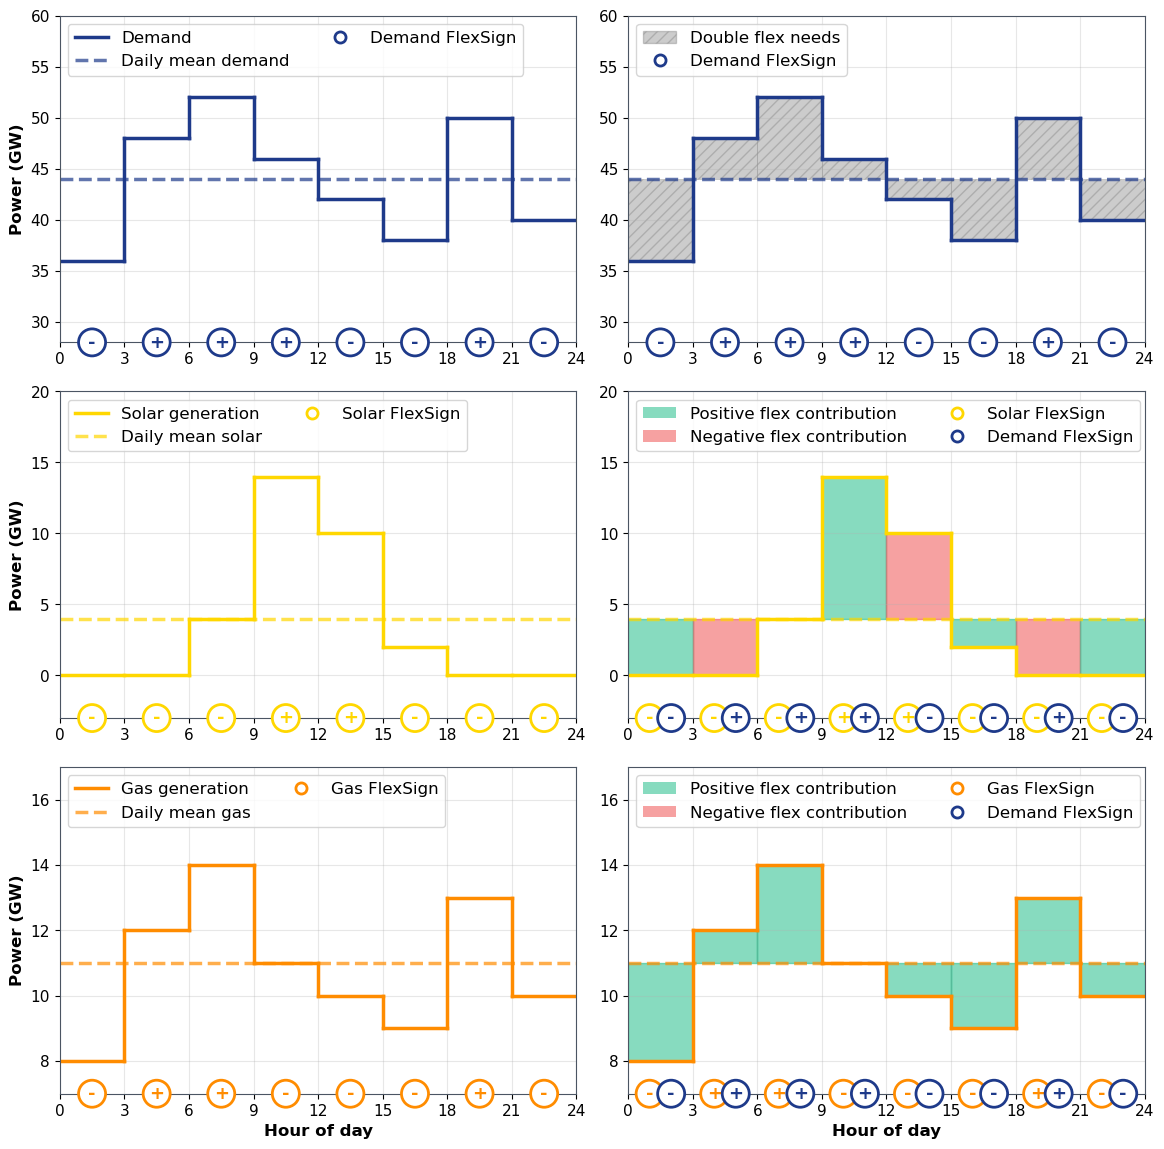

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# -----------------------
# Data setup - 3 hour resolution for one day
# -----------------------
np.random.seed(42)
start = pd.Timestamp('2019-01-01 00:00')
end = pd.Timestamp('2019-01-01 21:00')
t = pd.date_range(start, end, freq='3h')
hour = t.hour

# Net demand (residual load)
net_demand = np.array([36, 48, 52, 46, 42, 38, 50, 40])
net_demand = pd.Series(net_demand, index=t)
net_demand_mean = net_demand.mean()  # 44.0 GW

# Solar generation
solar = np.array([0, 0, 4, 14, 10, 2, 0, 0])
solar = pd.Series(solar, index=t)
solar_mean = 4.0

# Gas generation
gas = np.array([8, 12, 14, 11, 10, 9, 13, 10])
gas = pd.Series(gas, index=t)
gas_mean = 11.0

# Calculate flexibility signs
flex_sign = np.sign(net_demand - net_demand_mean)
prod_sign_solar = np.sign(solar - solar_mean)
prod_sign_gas = np.sign(gas - gas_mean)

# Calculate flexibility needs and contributions
flex_needs = 0.5 * np.sum(np.abs(net_demand - net_demand_mean)) * 3
solar_flex_curve = (solar - solar_mean) * flex_sign
gas_flex_curve = (gas - gas_mean) * flex_sign
solar_contribution = 0.5 * np.sum(solar_flex_curve) * 3
gas_contribution = 0.5 * np.sum(gas_flex_curve) * 3

print(f"Daily flexibility needs: {flex_needs:.1f} GWh")
print(f"Solar flexibility contribution: {solar_contribution:.1f} GWh")
print(f"Gas flexibility contribution: {gas_contribution:.1f} GWh")

# -----------------------
# Create the plot
# -----------------------
plt.rcParams.update({
    'font.size': 11,
    'axes.linewidth': 0.8,
})

fig = plt.figure(figsize=(14, 14))
gs = fig.add_gridspec(3, 2, hspace=0.15, wspace=0.1, height_ratios=[1, 1, 1])
axes = [[fig.add_subplot(gs[i, j]) for j in range(2)] for i in range(3)]

# Colors
c_net = '#1E3A8A'
c_solar = '#FFD700'
c_gas = '#FF8C00'
c_pos = '#10B981'
c_neg = '#EF4444'

# -----------------------
# Helper to draw step function
# -----------------------
def draw_step(ax, hour, values, color, lw=2.5):
    for i in range(len(hour)):
        if i < len(hour) - 1:
            ax.plot([hour[i], hour[i+1]], [values.iloc[i], values.iloc[i]], lw=lw, color=color)
            ax.plot([hour[i+1], hour[i+1]], [values.iloc[i], values.iloc[i+1]], lw=lw, color=color)
        else:
            ax.plot([hour[i], 24], [values.iloc[i], values.iloc[i]], lw=lw, color=color)

# -----------------------
# Helper to add FlexSign circles at bottom of axis
# -----------------------
def add_flexsign_circles(ax, hour, sign_array, color, y_pos, offset=0.0):
    for i in range(len(hour)):
        h_start = hour[i]
        h_end = hour[i+1] if i < len(hour) - 1 else 24
        h_center = (h_start + h_end) / 2 + offset
        sign_str = '+' if sign_array.iloc[i] > 0 else '-'
        ax.text(h_center, y_pos, sign_str, ha='center', va='center', fontsize=13,
                fontweight='bold', color=color,
                bbox=dict(boxstyle='circle,pad=0.25', facecolor='white',
                          edgecolor=color, linewidth=2), zorder=10)

# -----------------------
# Row 1: Net demand
# -----------------------
ax1 = axes[0][0]
draw_step(ax1, hour, net_demand, c_net)
ax1.plot([], [], lw=2.5, color=c_net, label='Demand')
ax1.axhline(net_demand_mean, ls='--', lw=2.5, color=c_net, alpha=0.7, label='Daily mean demand')

demand_ylim = (28, 60)
ax1.set_ylim(demand_ylim)

# Add Demand FlexSign circles in left column row 1
add_flexsign_circles(ax1, hour, flex_sign, c_net, y_pos=demand_ylim[0])

legend_elements_left1 = [
    Line2D([0], [0], lw=2.5, color=c_net, label='Demand'),
    Line2D([0], [0], lw=2.5, color=c_net, alpha=0.7, ls='--', label='Daily mean demand'),
    Line2D([0], [0], marker='o', color='white', markerfacecolor='white',
           markeredgecolor=c_net, markeredgewidth=2, markersize=8,
           label='Demand FlexSign', linestyle='None'),
]
ax1.legend(handles=legend_elements_left1, loc='upper left', frameon=True, ncol=2, fontsize=12)
ax1.set_ylabel('Power (GW)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 24)
ax1.set_xticks(range(0, 25, 3))

# Right panel: flex needs shading + FlexSign circles
ax1r = axes[0][1]
draw_step(ax1r, hour, net_demand, c_net)
ax1r.axhline(net_demand_mean, ls='--', lw=2.5, color=c_net, alpha=0.7)

for i in range(len(hour)):
    h_start = hour[i]
    h_end = hour[i+1] if i < len(hour) - 1 else 24
    nd = net_demand.iloc[i]
    ax1r.fill_between([h_start, h_end], [net_demand_mean, net_demand_mean], [nd, nd],
                      alpha=0.4, color='gray', hatch='///', edgecolor='gray', linewidth=0.5)

add_flexsign_circles(ax1r, hour, flex_sign, c_net, y_pos=demand_ylim[0])

legend_elements_net = [
    Patch(facecolor='gray', alpha=0.4, hatch='///', edgecolor='gray', label='Double flex needs'),
    Line2D([0], [0], marker='o', color='white', markerfacecolor='white',
           markeredgecolor=c_net, markeredgewidth=2, markersize=8,
           label='Demand FlexSign', linestyle='None')
]
ax1r.legend(handles=legend_elements_net, loc='upper left', frameon=True, fontsize=12)
ax1r.set_ylim(demand_ylim)
ax1r.grid(True, alpha=0.3)
ax1r.set_xlim(0, 24)
ax1r.set_xticks(range(0, 25, 3))

# -----------------------
# Row 2: Solar
# -----------------------
ax2 = axes[1][0]
draw_step(ax2, hour, solar, c_solar)
ax2.plot([], [], lw=2.5, color=c_solar, label='Solar generation')
ax2.axhline(solar_mean, ls='--', lw=2.5, color=c_solar, alpha=0.7, label='Daily mean solar')

solar_ylim = (-3, 20)
ax2.set_ylim(solar_ylim)

# Add only Solar FlexSign in left column
add_flexsign_circles(ax2, hour, prod_sign_solar, c_solar, y_pos=solar_ylim[0], offset=0.0)

legend_elements_left2 = [
    Line2D([0], [0], lw=2.5, color=c_solar, label='Solar generation'),
    Line2D([0], [0], lw=2.5, color=c_solar, alpha=0.7, ls='--', label='Daily mean solar'),
    Line2D([0], [0], marker='o', color='white', markerfacecolor='white',
           markeredgecolor=c_solar, markeredgewidth=2, markersize=8,
           label='Solar FlexSign', linestyle='None'),
]
ax2.legend(handles=legend_elements_left2, loc='upper left', frameon=True, ncol=2, fontsize=12)
ax2.set_ylabel('Power (GW)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 24)
ax2.set_xticks(range(0, 25, 3))

# Right panel: Solar contribution shading + FlexSigns
ax2r = axes[1][1]
draw_step(ax2r, hour, solar, c_solar)
ax2r.axhline(solar_mean, ls='--', lw=2.5, color=c_solar, alpha=0.7)

for i in range(len(hour)):
    h_start = hour[i]
    h_end = hour[i+1] if i < len(hour) - 1 else 24
    s = solar.iloc[i]
    fs = flex_sign.iloc[i]
    ps = prod_sign_solar.iloc[i]
    color = c_pos if fs * ps > 0 else c_neg
    ax2r.fill_between([h_start, h_end], [solar_mean, solar_mean], [s, s], alpha=0.5, color=color)

add_flexsign_circles(ax2r, hour, prod_sign_solar, c_solar, y_pos=solar_ylim[0], offset=-0.5)
add_flexsign_circles(ax2r, hour, flex_sign, c_net, y_pos=solar_ylim[0], offset=+0.5)

legend_elements_solar = [
    Patch(facecolor=c_pos, alpha=0.5, label='Positive flex contribution'),
    Patch(facecolor=c_neg, alpha=0.5, label='Negative flex contribution'),
    Line2D([0], [0], marker='o', color='white', markerfacecolor='white',
           markeredgecolor=c_solar, markeredgewidth=2, markersize=8,
           label='Solar FlexSign', linestyle='None'),
    Line2D([0], [0], marker='o', color='white', markerfacecolor='white',
           markeredgecolor=c_net, markeredgewidth=2, markersize=8,
           label='Demand FlexSign', linestyle='None')
]
ax2r.legend(handles=legend_elements_solar, loc='upper left', frameon=True, fontsize=12, ncol=2)
ax2r.set_ylim(solar_ylim)
ax2r.grid(True, alpha=0.3)
ax2r.set_xlim(0, 24)
ax2r.set_xticks(range(0, 25, 3))

# -----------------------
# Row 3: Gas
# -----------------------
ax3 = axes[2][0]
draw_step(ax3, hour, gas, c_gas)
ax3.plot([], [], lw=2.5, color=c_gas, label='Gas generation')
ax3.axhline(gas_mean, ls='--', lw=2.5, color=c_gas, alpha=0.7, label='Daily mean gas')

gas_ylim = (7, 17)
ax3.set_ylim(gas_ylim)

# Add only Gas FlexSign in left column
add_flexsign_circles(ax3, hour, prod_sign_gas, c_gas, y_pos=gas_ylim[0], offset=0.0)

legend_elements_left3 = [
    Line2D([0], [0], lw=2.5, color=c_gas, label='Gas generation'),
    Line2D([0], [0], lw=2.5, color=c_gas, alpha=0.7, ls='--', label='Daily mean gas'),
    Line2D([0], [0], marker='o', color='white', markerfacecolor='white',
           markeredgecolor=c_gas, markeredgewidth=2, markersize=8,
           label='Gas FlexSign', linestyle='None'),
]
ax3.legend(handles=legend_elements_left3, loc='upper left', frameon=True, ncol=2, fontsize=12)
ax3.set_ylabel('Power (GW)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Hour of day', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.set_xlim(0, 24)
ax3.set_xticks(range(0, 25, 3))

# Right panel: Gas contribution shading + FlexSigns
ax3r = axes[2][1]
draw_step(ax3r, hour, gas, c_gas)
ax3r.axhline(gas_mean, ls='--', lw=2.5, color=c_gas, alpha=0.7)

for i in range(len(hour)):
    h_start = hour[i]
    h_end = hour[i+1] if i < len(hour) - 1 else 24
    g = gas.iloc[i]
    fs = flex_sign.iloc[i]
    pg = prod_sign_gas.iloc[i]
    color = c_pos if fs * pg > 0 else c_neg
    ax3r.fill_between([h_start, h_end], [gas_mean, gas_mean], [g, g], alpha=0.5, color=color)

add_flexsign_circles(ax3r, hour, prod_sign_gas, c_gas, y_pos=gas_ylim[0], offset=-0.5)
add_flexsign_circles(ax3r, hour, flex_sign, c_net, y_pos=gas_ylim[0], offset=+0.5)

legend_elements_gas = [
    Patch(facecolor=c_pos, alpha=0.5, label='Positive flex contribution'),
    Patch(facecolor=c_neg, alpha=0.5, label='Negative flex contribution'),
    Line2D([0], [0], marker='o', color='white', markerfacecolor='white',
           markeredgecolor=c_gas, markeredgewidth=2, markersize=8,
           label='Gas FlexSign', linestyle='None'),
    Line2D([0], [0], marker='o', color='white', markerfacecolor='white',
           markeredgecolor=c_net, markeredgewidth=2, markersize=8,
           label='Demand FlexSign', linestyle='None')
]
ax3r.legend(handles=legend_elements_gas, loc='upper left', frameon=True, fontsize=12, ncol=2)
ax3r.set_xlabel('Hour of day', fontsize=12, fontweight='bold')
ax3r.set_ylim(gas_ylim)
ax3r.grid(True, alpha=0.3)
ax3r.set_xlim(0, 24)
ax3r.set_xticks(range(0, 25, 3))

# Remove y tick labels from right panels
for row in axes:
    row[1].set_yticklabels([])

plt.savefig('/home/julian-geis/Documents/06_PhD/02Flexibility/plots/methods/flex_contributions_methods.png', 
            dpi=300, bbox_inches='tight')
print("Plot saved.")

Daily flexibility needs:        30.0 GWh
Gas flexibility contribution:   36.0 GWh
Battery flexibility contribution: 18.0 GWh

Calculations:
Daily flexibility needs = 0.5 × (|6-5| + |7-5| + |9-5| + |2-5| + |1-5| + |3-5| + |8-5| + |4-5|) × 3h = 30.0 GWh
Gas flexibility contribution = 0.5 × (+1×+1 + +2×+1 + +5×+1 + -3×-1 + -3×-1 + -3×-1 + +4×+1 + -3×-1) × 3h = 36.0 GWh
Battery flexibility contribution = 0.5 × (+1.5×+1 + +1.5×+1 + +1.5×+1 + -1.5×-1 + -3.5×-1 + -2.5×-1 + +1.5×+1 + +1.5×-1) × 3h = 18.0 GWh


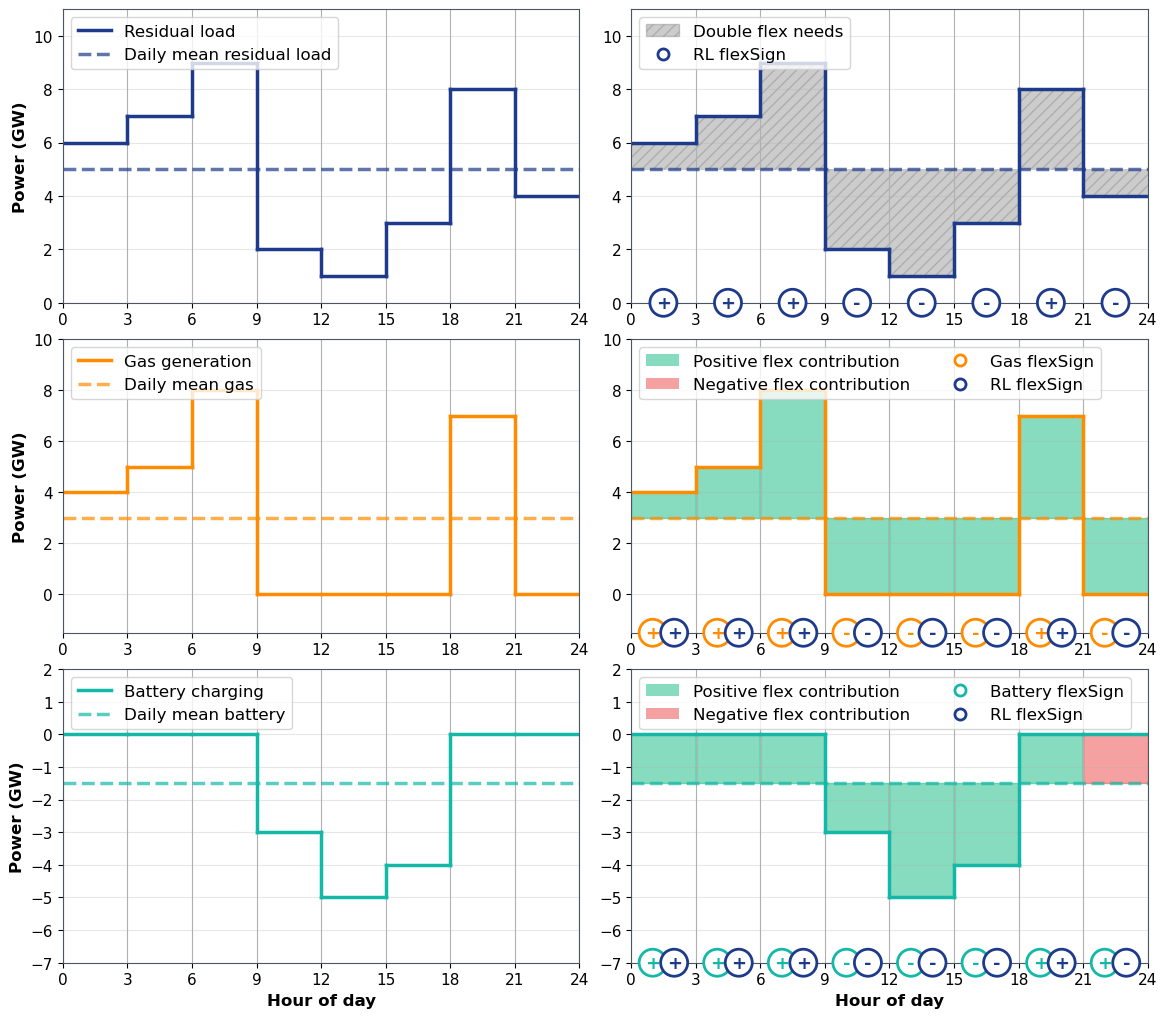

In [9]:
# -----------------------
# Data setup - 3 hour resolution for one day
# -----------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

np.random.seed(42)
start = pd.Timestamp('2019-01-01 00:00')
end   = pd.Timestamp('2019-01-01 21:00')
t     = pd.date_range(start, end, freq='3h')
hour  = t.hour

# Residual load - lowest during midday (solar feed-in effect), max 9 GW, mean = 5.0 GW
rl      = pd.Series(np.array([6, 7, 9, 2, 1, 3, 8, 4]), index=t)   # hours 0,3,6,9,12,15,18,21
rl_mean = rl.mean()   # 5.0 GW

# Gas generation - only runs during the 4 highest RL hours (0h,3h,6h,18h), zero otherwise, max 8 GW
gas      = pd.Series(np.array([4, 5, 8, 0, 0, 0, 7, 0]), index=t)
gas_mean = gas.mean()   # 3.0 GW

# Battery charging - negative GW (demand), charges during midday low-RL hours, max 5 GW
battery      = pd.Series(np.array([0, 0, 0, -3, -5, -4, 0, 0]), index=t)
battery_mean = battery.mean()   # -1.5 GW

# Flex signs
flex_sign         = np.sign(rl - rl_mean)
prod_sign_gas     = np.sign(gas - gas_mean)
prod_sign_battery = np.sign(battery - battery_mean)

# Flexibility needs and contributions (GWh)
flex_needs           = 0.5 * np.sum(np.abs(rl - rl_mean)) * 3          # 30.0 GWh
gas_flex_curve       = (gas - gas_mean) * flex_sign
battery_flex_curve   = (battery - battery_mean) * flex_sign
gas_contribution     = 0.5 * np.sum(gas_flex_curve) * 3                # 36.0 GWh
battery_contribution = 0.5 * np.sum(battery_flex_curve) * 3            # 18.0 GWh

print(f"Daily flexibility needs:        {flex_needs:.1f} GWh")
print(f"Gas flexibility contribution:   {gas_contribution:.1f} GWh")
print(f"Battery flexibility contribution: {battery_contribution:.1f} GWh")

# Helper functions
def format_num(val):
    return f"{int(val)}" if val == int(val) else f"{val:.1f}"

def format_with_sign(val):
    num_str = format_num(abs(val))
    return f"+{num_str}" if val >= 0 else f"-{num_str}"

# Calculation strings
flex_needs_calc = "Daily flexibility needs = 0.5 × ("
for i in range(len(hour)):
    flex_needs_calc += f"|{format_num(rl.iloc[i])}-{format_num(rl_mean)}|"
    if i < len(hour) - 1: flex_needs_calc += " + "
flex_needs_calc += f") × 3h = {flex_needs:.1f} GWh"

gas_calc = "Gas flexibility contribution = 0.5 × ("
for i in range(len(hour)):
    gas_calc += f"{format_with_sign(gas.iloc[i] - gas_mean)}×{int(flex_sign.iloc[i]):+d}"
    if i < len(hour) - 1: gas_calc += " + "
gas_calc += f") × 3h = {gas_contribution:.1f} GWh"

battery_calc = "Battery flexibility contribution = 0.5 × ("
for i in range(len(hour)):
    battery_calc += f"{format_with_sign(battery.iloc[i] - battery_mean)}×{int(flex_sign.iloc[i]):+d}"
    if i < len(hour) - 1: battery_calc += " + "
battery_calc += f") × 3h = {battery_contribution:.1f} GWh"

# -----------------------
# Create the plot
# -----------------------
plt.rcParams.update({'font.size': 11, 'axes.linewidth': 0.8})

fig  = plt.figure(figsize=(14, 14))
gs   = fig.add_gridspec(4, 2, hspace=0.15, wspace=0.1, height_ratios=[1, 1, 1, 0.3])
axes = [[fig.add_subplot(gs[i, j]) for j in range(2)] for i in range(3)]

# Colors
c_rl  = '#1E3A8A'   # dark blue  – residual load
c_gas = '#FF8C00'   # dark orange – gas
c_bat = '#14B8A6'   # teal        – battery
c_pos = '#10B981'   # green       – positive contribution
c_neg = '#EF4444'   # red         – negative contribution

# ── generic step-function plotter ─────────────────────────────────────────────
def plot_steps(ax, series, color):
    for i in range(len(hour)):
        h_end = hour[i+1] if i < len(hour)-1 else 24
        ax.plot([hour[i], h_end],       [series.iloc[i], series.iloc[i]], lw=2.5, color=color)
        if i < len(hour)-1:
            ax.plot([hour[i+1], hour[i+1]], [series.iloc[i], series.iloc[i+1]], lw=2.5, color=color)

def ax_style(ax, ylim, xlabel='', ylabel=''):
    ax.set_xlim(0, 24);  ax.set_xticks(range(0, 25, 3))
    ax.set_ylim(ylim);   ax.grid(True);  ax.grid(axis='y', alpha=0.3)
    ax.set_xlabel(xlabel, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')

# -----------------------
# Row 1: Residual load
# -----------------------
rl_ylim = (0, 11)

# Left – plain profile
ax = axes[0][0]
plot_steps(ax, rl, c_rl)
ax.plot([], [], lw=2.5, color=c_rl, label='Residual load')
ax.axhline(rl_mean, ls='--', lw=2.5, color=c_rl, alpha=0.7, label='Daily mean residual load')
ax.legend(loc='upper left', frameon=True, fontsize=12)
ax_style(ax, rl_ylim, ylabel='Power (GW)')

# Right – flex needs shading + flexSign circles
ax = axes[0][1]
plot_steps(ax, rl, c_rl)
ax.axhline(rl_mean, ls='--', lw=2.5, color=c_rl, alpha=0.7)
for i in range(len(hour)):
    h_start = hour[i];  h_end = hour[i+1] if i < len(hour)-1 else 24
    ax.fill_between([h_start, h_end], [rl_mean, rl_mean], [rl.iloc[i], rl.iloc[i]],
                    alpha=0.4, color='gray', hatch='///', edgecolor='gray', linewidth=0.5)
    sign = '+' if flex_sign.iloc[i] > 0 else '-'
    ax.text((h_start+h_end)/2, rl_ylim[0], sign, ha='center', va='center',
            fontsize=13, fontweight='bold', color=c_rl,
            bbox=dict(boxstyle='circle,pad=0.25', facecolor='white', edgecolor=c_rl, linewidth=2))
ax.legend(handles=[
    Patch(facecolor='gray', alpha=0.4, hatch='///', edgecolor='gray', label='Double flex needs'),
    Line2D([0],[0], marker='o', color='white', markerfacecolor='white',
           markeredgecolor=c_rl, markeredgewidth=2, markersize=8,
           label='RL flexSign', linestyle='None'),
], loc='upper left', frameon=True, fontsize=12)
ax_style(ax, rl_ylim)

# -----------------------
# Row 2: Gas generation
# -----------------------
gas_ylim = (-1.5, 10)

# Left – plain profile
ax = axes[1][0]
plot_steps(ax, gas, c_gas)
ax.plot([], [], lw=2.5, color=c_gas, label='Gas generation')
ax.axhline(gas_mean, ls='--', lw=2.5, color=c_gas, alpha=0.7, label='Daily mean gas')
ax.legend(loc='upper left', frameon=True, fontsize=12)
ax_style(ax, gas_ylim, ylabel='Power (GW)')

# Right – contribution shading + flexSign circles
ax = axes[1][1]
plot_steps(ax, gas, c_gas)
ax.axhline(gas_mean, ls='--', lw=2.5, color=c_gas, alpha=0.7)
for i in range(len(hour)):
    h_start = hour[i];  h_end = hour[i+1] if i < len(hour)-1 else 24
    h_center = (h_start + h_end) / 2
    fs = flex_sign.iloc[i];  pg = prod_sign_gas.iloc[i]
    ax.fill_between([h_start, h_end], [gas_mean, gas_mean], [gas.iloc[i], gas.iloc[i]],
                    alpha=0.5, color=c_pos if fs * pg > 0 else c_neg)
    ax.text(h_center - 0.5, gas_ylim[0], '+' if pg > 0 else '-',
            ha='center', va='center', fontsize=13, fontweight='bold', color=c_gas,
            bbox=dict(boxstyle='circle,pad=0.25', facecolor='white', edgecolor=c_gas, linewidth=2), zorder=10)
    ax.text(h_center + 0.5, gas_ylim[0], '+' if fs > 0 else '-',
            ha='center', va='center', fontsize=13, fontweight='bold', color=c_rl,
            bbox=dict(boxstyle='circle,pad=0.25', facecolor='white', edgecolor=c_rl,  linewidth=2), zorder=11)
ax.legend(handles=[
    Patch(facecolor=c_pos, alpha=0.5, label='Positive flex contribution'),
    Patch(facecolor=c_neg, alpha=0.5, label='Negative flex contribution'),
    Line2D([0],[0], marker='o', color='white', markerfacecolor='white',
           markeredgecolor=c_gas, markeredgewidth=2, markersize=8, label='Gas flexSign', linestyle='None'),
    Line2D([0],[0], marker='o', color='white', markerfacecolor='white',
           markeredgecolor=c_rl,  markeredgewidth=2, markersize=8, label='RL flexSign',  linestyle='None'),
], loc='upper left', frameon=True, fontsize=12, ncol=2)
ax_style(ax, gas_ylim)

# -----------------------
# Row 3: Battery charging
# -----------------------
battery_ylim = (-7, 2)

# Left – plain profile
ax = axes[2][0]
plot_steps(ax, battery, c_bat)
ax.plot([], [], lw=2.5, color=c_bat, label='Battery charging')
ax.axhline(battery_mean, ls='--', lw=2.5, color=c_bat, alpha=0.7, label='Daily mean battery')
ax.legend(loc='upper left', frameon=True, fontsize=12)
ax_style(ax, battery_ylim, xlabel='Hour of day', ylabel='Power (GW)')

# Right – contribution shading + flexSign circles
ax = axes[2][1]
plot_steps(ax, battery, c_bat)
ax.axhline(battery_mean, ls='--', lw=2.5, color=c_bat, alpha=0.7)
for i in range(len(hour)):
    h_start = hour[i];  h_end = hour[i+1] if i < len(hour)-1 else 24
    h_center = (h_start + h_end) / 2
    fs = flex_sign.iloc[i];  pb = prod_sign_battery.iloc[i]
    ax.fill_between([h_start, h_end], [battery_mean, battery_mean], [battery.iloc[i], battery.iloc[i]],
                    alpha=0.5, color=c_pos if fs * pb > 0 else c_neg)
    ax.text(h_center - 0.5, battery_ylim[0], '+' if pb > 0 else '-',
            ha='center', va='center', fontsize=13, fontweight='bold', color=c_bat,
            bbox=dict(boxstyle='circle,pad=0.25', facecolor='white', edgecolor=c_bat, linewidth=2), zorder=10)
    ax.text(h_center + 0.5, battery_ylim[0], '+' if fs > 0 else '-',
            ha='center', va='center', fontsize=13, fontweight='bold', color=c_rl,
            bbox=dict(boxstyle='circle,pad=0.25', facecolor='white', edgecolor=c_rl,  linewidth=2), zorder=11)
ax.legend(handles=[
    Patch(facecolor=c_pos, alpha=0.5, label='Positive flex contribution'),
    Patch(facecolor=c_neg, alpha=0.5, label='Negative flex contribution'),
    Line2D([0],[0], marker='o', color='white', markerfacecolor='white',
           markeredgecolor=c_bat, markeredgewidth=2, markersize=8, label='Battery flexSign', linestyle='None'),
    Line2D([0],[0], marker='o', color='white', markerfacecolor='white',
           markeredgecolor=c_rl,  markeredgewidth=2, markersize=8, label='RL flexSign',      linestyle='None'),
], loc='upper left', frameon=True, fontsize=12, ncol=2)
ax_style(ax, battery_ylim, xlabel='Hour of day')

# -----------------------
# Calculation text box (commented out, kept for reference)
# -----------------------
# calc_ax = fig.add_subplot(gs[3, :])
# calc_ax.axis('off')
# calc_text = f"{flex_needs_calc}\n\n{gas_calc}\n\n{battery_calc}"
# calc_ax.text(-0.02, 0, calc_text, transform=calc_ax.transAxes,
#             ha='left', va='center', fontsize=10.5,
#             bbox=dict(boxstyle='round,pad=0.6', facecolor='white', edgecolor='gray', linewidth=2),
#             family='monospace')

plt.savefig('/home/julian-geis/Documents/06_PhD/02Flexibility/plots/methods/flex_contributions_methods.png',
            dpi=300, bbox_inches='tight')
print(f"\nCalculations:\n{flex_needs_calc}\n{gas_calc}\n{battery_calc}")
plt.show()

Flex needs:   30.0 GWh
Gas:          4.5 GWh
Battery:      9.0 GWh
Heat pump:    -3.0 GWh


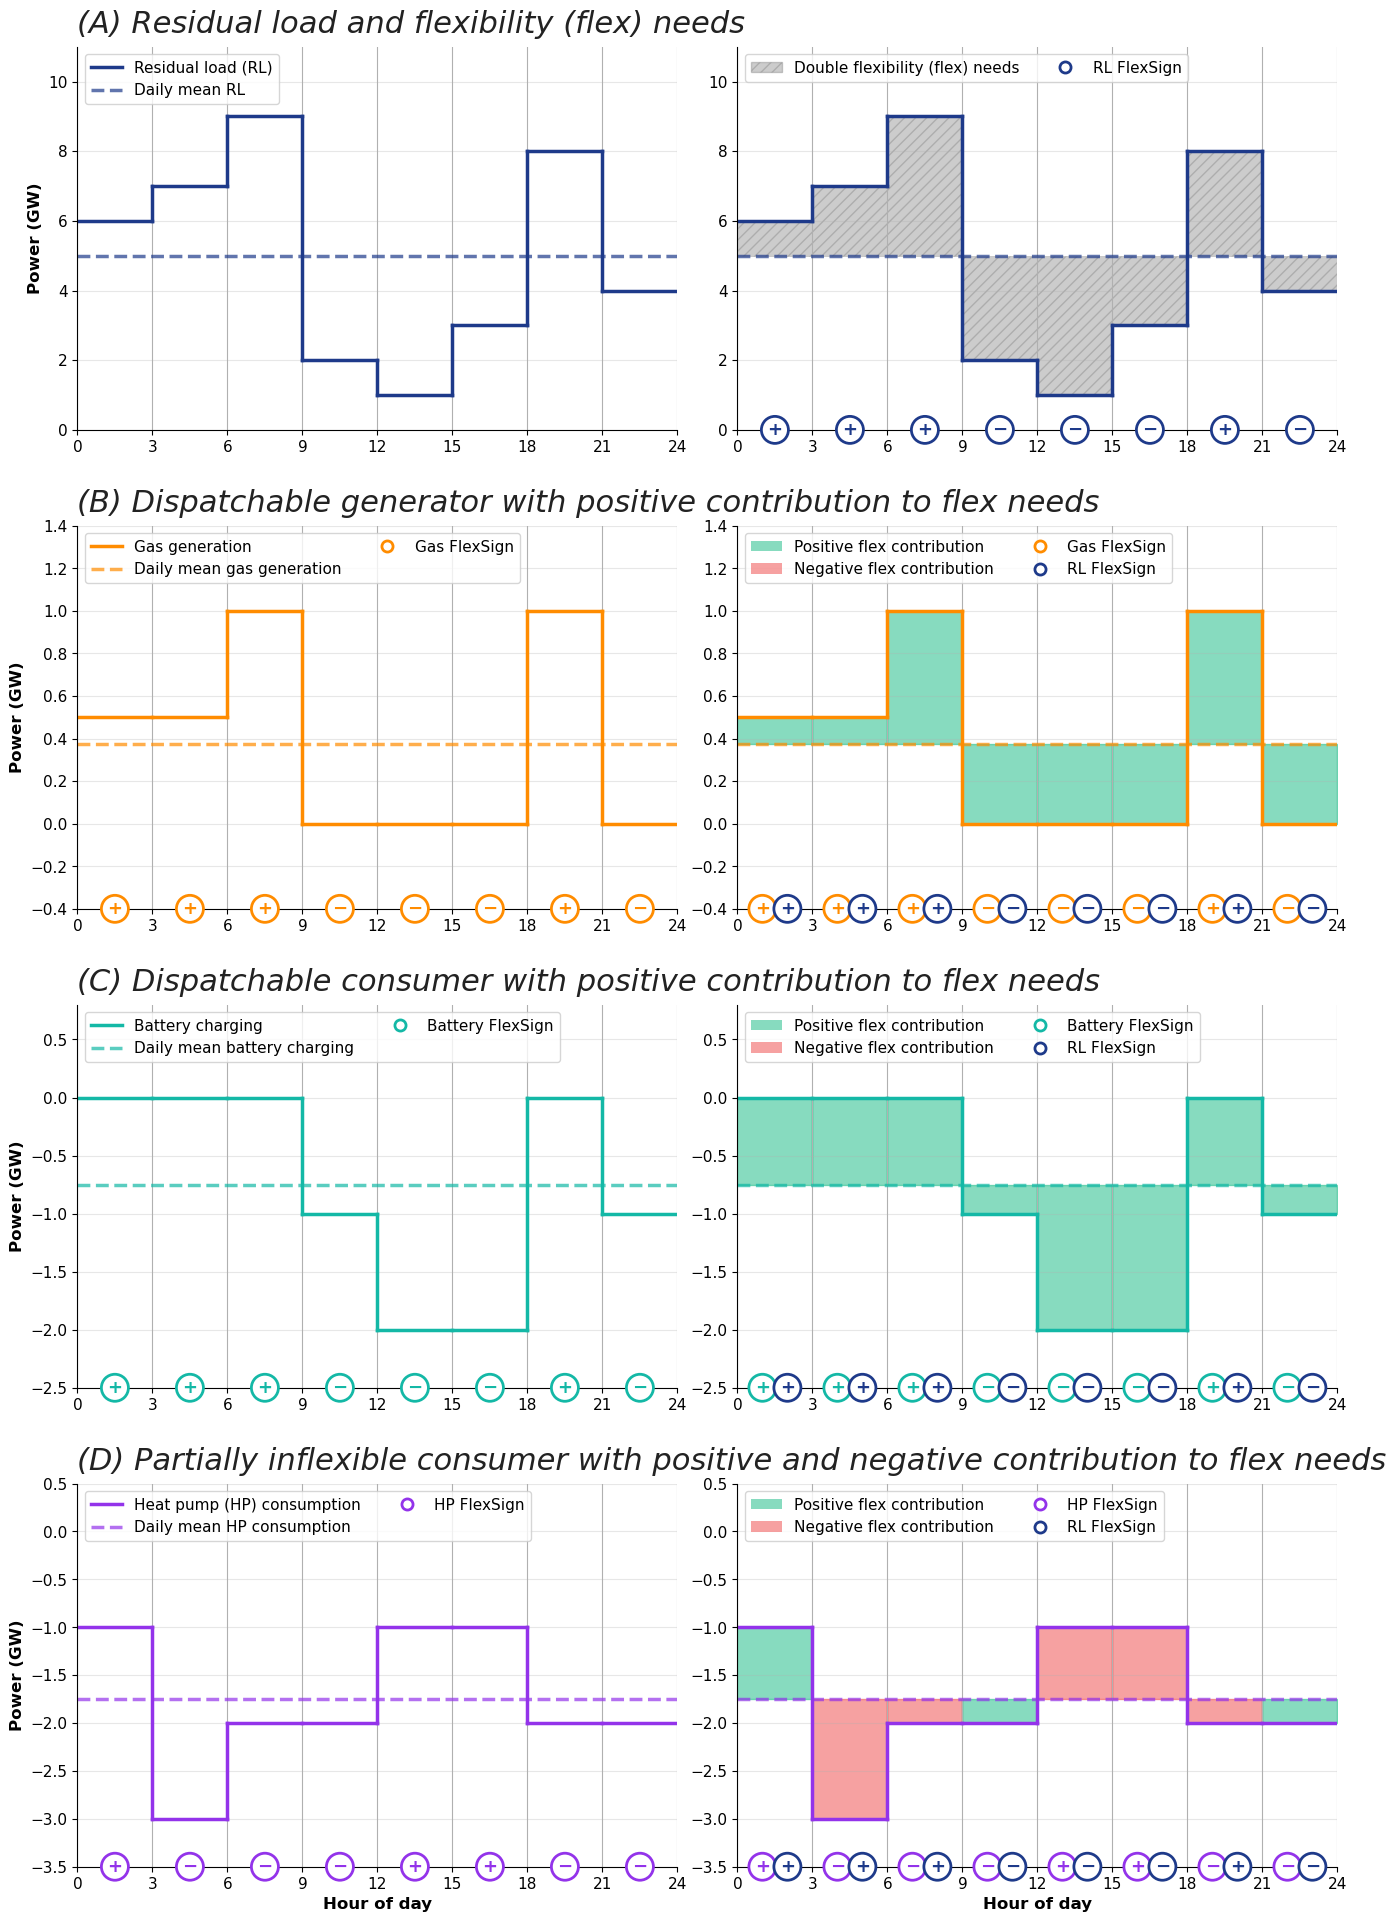

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# ══════════════════════════════════════════════════════════════════════════════
# ▶  Layout knobs
# ══════════════════════════════════════════════════════════════════════════════
TITLE_FONTSIZE = 22    # row-title font size
ROW_HSPACE     = 0.25  # vertical gap between rows (larger = more space)
# ══════════════════════════════════════════════════════════════════════════════

# ── Data ──────────────────────────────────────────────────────────────────────
np.random.seed(42)
start = pd.Timestamp('2019-01-01 00:00')
end   = pd.Timestamp('2019-01-01 21:00')
t     = pd.date_range(start, end, freq='3h')
hour  = t.hour

# Residual load — unchanged; flex_needs = 30 GWh
rl      = pd.Series([6, 7, 9, 2, 1, 3, 8, 4], index=t, dtype=float)
rl_mean = rl.mean()   # 5.0 GW

# Gas — scaled down → contribution ≈ 4.5 GWh  (was 9 GWh)
gas      = pd.Series([0.5, 0.5, 1.0, 0, 0, 0, 1.0, 0], index=t, dtype=float)
gas_mean = gas.mean() # 0.375 GW

# Battery — unchanged → contribution = 9.0 GWh
battery      = pd.Series([0, 0, 0, -1, -2, -2, 0, -1], index=t, dtype=float)
battery_mean = battery.mean() # -0.75 GW

# Heat pump — redesigned so it peaks in the morning and stays modest
# → contribution ≈ -3.0 GWh  (was -9 GWh), still mixed green/red areas
hp      = pd.Series([-1, -3, -2, -2, -1, -1, -2, -2], index=t, dtype=float)
hp_mean = hp.mean()   # -1.75 GW

# ── Flex signs ────────────────────────────────────────────────────────────────
flex_sign     = np.sign(rl - rl_mean)
prod_sign_gas = np.sign(gas - gas_mean)
prod_sign_bat = np.sign(battery - battery_mean)
prod_sign_hp  = np.sign(hp - hp_mean)

# ── Contributions ─────────────────────────────────────────────────────────────
flex_needs       = 0.5 * np.sum(np.abs(rl - rl_mean))                * 3
gas_contribution = 0.5 * np.sum((gas     - gas_mean)     * flex_sign) * 3
bat_contribution = 0.5 * np.sum((battery - battery_mean) * flex_sign) * 3
hp_contribution  = 0.5 * np.sum((hp      - hp_mean)      * flex_sign) * 3

print(f"Flex needs:   {flex_needs:.1f} GWh")
print(f"Gas:          {gas_contribution:.1f} GWh")
print(f"Battery:      {bat_contribution:.1f} GWh")
print(f"Heat pump:    {hp_contribution:.1f} GWh")

# ── Colors ────────────────────────────────────────────────────────────────────
c_rl  = '#1E3A8A'
c_gas = '#FF8C00'
c_bat = '#14B8A6'
c_hp  = '#9333EA'
c_pos = '#10B981'
c_neg = '#EF4444'

plt.rcParams.update({'font.size': 11, 'axes.linewidth': 0.8})

# ── y-limits — tuned so circles fit, zero-line reads cleanly, no clipping ─────
rl_ylim      = (0,    11)
gas_ylim     = (-0.4,  1.4)   # gas:     0 – 1.0 GW, circles at –0.4
battery_ylim = (-2.5,  0.8)   # battery: –2 – 0 GW, circles at –2.5; 0.8 headroom for legend
hp_ylim      = (-3.5,  0.5)   # HP:      –3 – –1 GW, circles at –3.5

# ── Helpers ───────────────────────────────────────────────────────────────────
def plot_steps(ax, series, color):
    for i in range(len(hour)):
        h_end = hour[i+1] if i < len(hour)-1 else 24
        ax.plot([hour[i], h_end], [series.iloc[i], series.iloc[i]], lw=2.5, color=color)
        if i < len(hour)-1:
            ax.plot([hour[i+1], hour[i+1]], [series.iloc[i], series.iloc[i+1]], lw=2.5, color=color)

def ax_style(ax, ylim, xlabel='', ylabel=''):
    ax.set_xlim(0, 24); ax.set_xticks(range(0, 25, 3))
    ax.set_ylim(ylim);  ax.grid(True); ax.grid(axis='y', alpha=0.3)
    ax.set_xlabel(xlabel, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def sign_circle(ax, x, y, sign_val, color):
    """Draw a ± circle at data coords (x, y)."""
    ax.text(x, y, '+' if sign_val > 0 else '−',
            ha='center', va='center', fontsize=13, fontweight='bold', color=color,
            bbox=dict(boxstyle='circle,pad=0.25', facecolor='white',
                      edgecolor=color, linewidth=2), zorder=10)

def add_tech_signs_left(ax, ylim, prod_sign, c_tech):
    """Add one tech-sign circle per block to the left column."""
    for i in range(len(hour)):
        h_start  = hour[i]
        h_end    = hour[i+1] if i < len(hour)-1 else 24
        h_center = (h_start + h_end) / 2
        sign_circle(ax, h_center, ylim[0], prod_sign.iloc[i], c_tech)

def left_legend(ax, line_label, mean_label, sign_label, c_tech, loc='upper left'):
    """3-item, 2-column legend for left-column tech plots."""
    ax.legend(handles=[
        Line2D([0],[0], lw=2.5, color=c_tech, label=line_label),
        Line2D([0],[0], ls='--', lw=2.5, color=c_tech, alpha=0.7, label=mean_label),
        Line2D([0],[0], marker='o', color='white', markerfacecolor='white',
               markeredgecolor=c_tech, markeredgewidth=2, markersize=8,
               label=sign_label, linestyle='None'),
    ], loc=loc, frameon=True, fontsize=11, ncol=2)

def plot_contribution_right(ax, series, series_mean, c_tech, ylim,
                             flex_sign, prod_sign, label_tech):
    """Right column: coloured fill + paired sign circles + 2-row legend."""
    plot_steps(ax, series, c_tech)
    ax.axhline(series_mean, ls='--', lw=2.5, color=c_tech, alpha=0.7)

    for i in range(len(hour)):
        h_start  = hour[i]
        h_end    = hour[i+1] if i < len(hour)-1 else 24
        h_center = (h_start + h_end) / 2
        fs = flex_sign.iloc[i]; ps = prod_sign.iloc[i]
        color = c_pos if fs * ps > 0 else c_neg
        ax.fill_between([h_start, h_end],
                        [series_mean, series_mean], [series.iloc[i], series.iloc[i]],
                        alpha=0.5, color=color)
        sign_circle(ax, h_center - 0.5, ylim[0], ps, c_tech)
        sign_circle(ax, h_center + 0.5, ylim[0], fs, c_rl)

    # 4-item, 2-column → exactly 2 rows
    ax.legend(handles=[
        Patch(facecolor=c_pos, alpha=0.5, label='Positive flex contribution'),
        Patch(facecolor=c_neg, alpha=0.5, label='Negative flex contribution'),
        Line2D([0],[0], marker='o', color='white', markerfacecolor='white',
               markeredgecolor=c_tech, markeredgewidth=2, markersize=8,
               label=label_tech, linestyle='None'),
        Line2D([0],[0], marker='o', color='white', markerfacecolor='white',
               markeredgecolor=c_rl, markeredgewidth=2, markersize=8,
               label='RL FlexSign', linestyle='None'),
    ], loc='upper left', frameon=True, fontsize=11, ncol=2)

# ── Figure ─────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 20))
gs  = fig.add_gridspec(4, 2,
                        hspace=ROW_HSPACE, wspace=0.1,
                        top=0.96, bottom=0.05, left=0.08, right=0.98)
axes = [[fig.add_subplot(gs[i, j]) for j in range(2)] for i in range(4)]

# ── Row 0: Residual load ──────────────────────────────────────────────────────
ax = axes[0][0]
plot_steps(ax, rl, c_rl)
ax.axhline(rl_mean, ls='--', lw=2.5, color=c_rl, alpha=0.7)
ax.legend(handles=[
    Line2D([0],[0], lw=2.5, color=c_rl, label='Residual load (RL)'),
    Line2D([0],[0], ls='--', lw=2.5, color=c_rl, alpha=0.7, label='Daily mean RL'),
], loc='upper left', frameon=True, fontsize=11, ncol=1)   # 2 items → 2 rows with ncol=1
ax_style(ax, rl_ylim, ylabel='Power (GW)')

ax = axes[0][1]
plot_steps(ax, rl, c_rl)
ax.axhline(rl_mean, ls='--', lw=2.5, color=c_rl, alpha=0.7)
for i in range(len(hour)):
    h_start = hour[i]; h_end = hour[i+1] if i < len(hour)-1 else 24
    ax.fill_between([h_start, h_end], [rl_mean, rl_mean], [rl.iloc[i], rl.iloc[i]],
                    alpha=0.4, color='gray', hatch='///', edgecolor='gray', linewidth=0.5)
    sign_circle(ax, (h_start+h_end)/2, rl_ylim[0], flex_sign.iloc[i], c_rl)
ax.legend(handles=[
    Patch(facecolor='gray', alpha=0.4, hatch='///', edgecolor='gray', label='Double flexibility (flex) needs'),
    Line2D([0],[0], marker='o', color='white', markerfacecolor='white',
           markeredgecolor=c_rl, markeredgewidth=2, markersize=8,
           label='RL FlexSign', linestyle='None'),
], loc='upper left', frameon=True, fontsize=11, ncol=2)
ax_style(ax, rl_ylim)

# ── Row 1: Gas ────────────────────────────────────────────────────────────────
ax = axes[1][0]
plot_steps(ax, gas, c_gas)
ax.axhline(gas_mean, ls='--', lw=2.5, color=c_gas, alpha=0.7)
add_tech_signs_left(ax, gas_ylim, prod_sign_gas, c_gas)
left_legend(ax, 'Gas generation', 'Daily mean gas generation', 'Gas FlexSign', c_gas)
ax_style(ax, gas_ylim, ylabel='Power (GW)')

ax = axes[1][1]
plot_contribution_right(ax, gas, gas_mean, c_gas, gas_ylim,
                         flex_sign, prod_sign_gas, label_tech='Gas FlexSign')
ax_style(ax, gas_ylim)

# ── Row 2: Battery ────────────────────────────────────────────────────────────
ax = axes[2][0]
plot_steps(ax, battery, c_bat)
ax.axhline(battery_mean, ls='--', lw=2.5, color=c_bat, alpha=0.7)
add_tech_signs_left(ax, battery_ylim, prod_sign_bat, c_bat)
left_legend(ax, 'Battery charging', 'Daily mean battery charging', 'Battery FlexSign', c_bat)
ax_style(ax, battery_ylim, ylabel='Power (GW)')

ax = axes[2][1]
plot_contribution_right(ax, battery, battery_mean, c_bat, battery_ylim,
                         flex_sign, prod_sign_bat, label_tech='Battery FlexSign')
ax_style(ax, battery_ylim)

# ── Row 3: Heat pump ──────────────────────────────────────────────────────────
ax = axes[3][0]
plot_steps(ax, hp, c_hp)
ax.axhline(hp_mean, ls='--', lw=2.5, color=c_hp, alpha=0.7)
add_tech_signs_left(ax, hp_ylim, prod_sign_hp, c_hp)
left_legend(ax, 'Heat pump (HP) consumption', 'Daily mean HP consumption', 'HP FlexSign', c_hp)
ax_style(ax, hp_ylim, xlabel='Hour of day', ylabel='Power (GW)')

ax = axes[3][1]
plot_contribution_right(ax, hp, hp_mean, c_hp, hp_ylim,
                         flex_sign, prod_sign_hp, label_tech='HP FlexSign')
ax_style(ax, hp_ylim, xlabel='Hour of day')

# ── Row titles (A)–(D): left-aligned, just above each row ────────────────────
row_titles = {
    0: "(A) Residual load and flexibility (flex) needs",
    1: "(B) Dispatchable generator with positive contribution to flex needs",
    2: "(C) Dispatchable consumer with positive contribution to flex needs",
    3: "(D) Partially inflexible consumer with positive and negative contribution to flex needs",
}

fig.canvas.draw()
for row_idx, title in row_titles.items():
    pos_l = axes[row_idx][0].get_position()
    x_left = pos_l.x0
    y_pos  = pos_l.y1 + 0.004   # small gap above top of axes box
    fig.text(x_left, y_pos, title,
             ha='left', va='bottom',
             fontsize=TITLE_FONTSIZE, style='italic', color='#222222',
             fontweight='normal',
             transform=fig.transFigure)

plt.savefig(
    '/home/julian-geis/Documents/06_PhD/02Flexibility/plots/methods/flex_contributions_methods.png',
    dpi=300, bbox_inches='tight',
)
plt.show()

In [5]:
# ── Paste this cell AFTER the data/calculation block in flex_contributions_methods_v2.py ──
# Requires: rl, rl_mean, gas, gas_mean, battery, battery_mean, hp, hp_mean,
#           flex_sign, prod_sign_gas, prod_sign_bat, prod_sign_hp,
#           flex_needs, gas_contribution, bat_contribution, hp_contribution

def format_num(val):
    """Format value without trailing .0 where possible."""
    if val == int(val):
        return f"{int(val)}"
    return f"{val:.2f}".rstrip('0').rstrip('.')

def format_signed(val):
    s = format_num(abs(val))
    return f"+{s}" if val >= 0 else f"-{s}"

def build_needs_str(series, mean, label, total):
    parts = " + ".join(f"|{format_num(v)}-{format_num(mean)}|" for v in series)
    return (f"{label} = 0.5 × ({parts}) × 3h\n"
            f"{'':>{len(label)+4}}= {total:.1f} GWh")

def build_contrib_str(series, mean, flex_sign, label, total):
    parts = " + ".join(
        f"({format_signed(v - mean)}×{int(fs):+d})"
        for v, fs in zip(series, flex_sign)
    )
    return (f"{label} = 0.5 × ({parts}) × 3h\n"
            f"{'':>{len(label)+4}}= {total:.1f} GWh")

# ── Build strings ─────────────────────────────────────────────────────────────
needs_str = build_needs_str(rl, rl_mean,
    "Flexibility needs                     ", flex_needs)

gas_str   = build_contrib_str(gas, gas_mean, flex_sign,
    "Gas flexibility contribution          ", gas_contribution)

bat_str   = build_contrib_str(battery, battery_mean, flex_sign,
    "Battery flexibility contribution      ", bat_contribution)

hp_str    = build_contrib_str(hp, hp_mean, flex_sign,
    "Heat pump flexibility contribution    ", hp_contribution)

# ── Print ─────────────────────────────────────────────────────────────────────
separator = "─" * 100
print(separator)
print(needs_str)
print(separator)
print(gas_str)
print()
print(bat_str)
print()
print(hp_str)
print(separator)

────────────────────────────────────────────────────────────────────────────────────────────────────
Flexibility needs                      = 0.5 × (|6-5| + |7-5| + |9-5| + |2-5| + |1-5| + |3-5| + |8-5| + |4-5|) × 3h
                                          = 30.0 GWh
────────────────────────────────────────────────────────────────────────────────────────────────────
Gas flexibility contribution           = 0.5 × ((+0.12×+1) + (+0.12×+1) + (+0.62×+1) + (-0.38×-1) + (-0.38×-1) + (-0.38×-1) + (+0.62×+1) + (-0.38×-1)) × 3h
                                          = 4.5 GWh

Battery flexibility contribution       = 0.5 × ((+0.75×+1) + (+0.75×+1) + (+0.75×+1) + (-0.25×-1) + (-1.25×-1) + (-1.25×-1) + (+0.75×+1) + (-0.25×-1)) × 3h
                                          = 9.0 GWh

Heat pump flexibility contribution     = 0.5 × ((+0.75×+1) + (-1.25×+1) + (-0.25×+1) + (-0.25×-1) + (+0.75×-1) + (+0.75×-1) + (-0.25×+1) + (-0.25×-1)) × 3h
                                          = -3.0 GWh
──